# Indian Railway Delay Prediction
## Classification — Review 1

### Problem Statement

The objective is to predict whether an Indian Railway journey is delayed using the journey, route, infrastructure, weather-risk, operational, and historical performance attributes in the supplied dataset.

The target variable is `is_delayed`, where `0` represents not delayed and `1` represents delayed.

## 1. Objectives

- Perform structured EDA to understand the dataset and feature-target relationships.
- Clean and preprocess the data using leakage-safe practices, with preprocessing fitted only on the training data.
- Check missing values, duplicate records, and outliers.
- Create at least one meaningful engineered feature.
- Train and evaluate the five Review-1 Classification Part-A algorithms:
  1. Logistic Regression
  2. K-Nearest Neighbors
  3. Gaussian Naive Bayes
  4. Decision Tree Classifier
  5. Support Vector Classifier
- Tune selected hyperparameters using GridSearchCV.
- Compare the models using Accuracy, Precision, Recall, Weighted F1-score, ROC-AUC, and Confusion Matrix.
- Perform five-fold cross-validation for the two best-performing preliminary models.
- Keep the workflow reproducible using `random_state=42`.

**Dataset-size note:** The supplied dataset contains 1.5 million rows. To make KNN, SVC, GridSearchCV, and plotting computationally practical, the notebook keeps the official stratified 80:20 split on the full cleaned dataset, then uses one fixed stratified subset of the training portion for computationally expensive model fitting/tuning and one fixed stratified subset of the held-out test portion for a common model comparison. The subset is selected once with `random_state=42`, so all five models are compared on exactly the same observations.

## 2. Import Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification models - Part A
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# Dimensionality reduction for dense GaussianNB/SVC pipelines
from sklearn.decomposition import TruncatedSVD

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot settings
sns.set_palette("colorblind")
plt.rcParams["figure.figsize"] = (10, 6)


## 3. Load Dataset

In [2]:
TRAIN_FILE = "ir_train_siddu.csv"

df = pd.read_csv(TRAIN_FILE)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Dataset shape: (1500000, 45)


,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,...,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes,is_delayed
0,IR01717809,12536,Superfast Express,2023-09-18,2023,9,0,7,0,0,...,1,5.5,88.8,0,0,0,67.8,Flooding / Waterlogging,110,1
1,IR00931776,12806,Superfast Express,2020-04-09,2020,4,3,8,0,0,...,1,6.6,83.6,0,0,0,57.0,On Time,3,0
2,IR00096904,22416,Vande Bharat Express,2024-12-13,2024,12,4,18,0,0,...,0,4.1,81.6,0,0,0,81.8,On Time,5,0
3,IR00047736,12250,Garib Rath Express,2018-11-29,2018,11,3,18,0,0,...,0,5.5,82.1,0,1,0,52.3,Track Congestion,135,1
4,IR00726037,74588,DEMU/MEMU,2020-06-18,2020,6,3,5,0,0,...,1,8.0,58.3,0,1,0,64.3,Track Congestion,154,1


## 4. Dataset Audit

The dataset is examined to understand its dimensions, data types, missing values, duplicate records, and descriptive statistics before modelling.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1500000
Number of columns: 45


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 45 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   journey_id                    1500000 non-null  object 
 1   train_number                  1500000 non-null  int64  
 2   train_type                    1500000 non-null  object 
 3   departure_date                1500000 non-null  object 
 4   year                          1500000 non-null  int64  
 5   month                         1500000 non-null  int64  
 6   day_of_week                   1500000 non-null  int64  
 7   departure_hour                1500000 non-null  int64  
 8   is_weekend                    1500000 non-null  int64  
 9   is_night_departure            1500000 non-null  int64  
 10  is_peak_hour                  1500000 non-null  int64  
 11  is_festival_season            1500000 non-null  int64  
 12  season                      

### Missing Values

In [5]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

display(missing_values)

,Missing Count,Missing Percentage
journey_id,0,0.0
train_number,0,0.0
train_type,0,0.0
departure_date,0,0.0
year,0,0.0
month,0,0.0
day_of_week,0,0.0
departure_hour,0,0.0
is_weekend,0,0.0
is_night_departure,0,0.0


### Observation

The supplied dataset audit shows no missing values. Therefore, no missing-value imputation is required for the current dataset. The missing-value check is retained in the workflow so the notebook explicitly documents the audit.

### Duplicate Records

In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
journey_id,1500000,1500000,IR01717809,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_number,1500000.0,NaN,NaN,NaN,23665.976935,21036.932793,11100.0,11900.0,12647.0,22221.0,82998.0
train_type,1500000,15,Mail/Express,421047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_date,1500000,2556,2018-08-02,688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1500000.0,NaN,NaN,NaN,2021.002774,2.000014,2018.0,2019.0,2021.0,2023.0,2024.0
month,1500000.0,NaN,NaN,NaN,6.517572,3.448396,1.0,4.0,7.0,10.0,12.0
day_of_week,1500000.0,NaN,NaN,NaN,3.000643,2.001999,0.0,1.0,3.0,5.0,6.0
departure_hour,1500000.0,NaN,NaN,NaN,13.112735,5.832482,0.0,8.0,14.0,18.0,23.0
is_weekend,1500000.0,NaN,NaN,NaN,0.286304,0.452033,0.0,0.0,0.0,1.0,1.0
is_night_departure,1500000.0,NaN,NaN,NaN,0.100677,0.3009,0.0,0.0,0.0,0.0,1.0


## 5. Target Variable Analysis

### Target Values

In [9]:
TARGET = "is_delayed"

print("Target value counts:")
display(df[TARGET].value_counts().sort_index())

Target value counts:


is_delayed
0     421671
1    1078329
Name: count, dtype: int64

### Target Class Percentage

In [10]:
target_percentage = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename("Percentage")
)

display(target_percentage)

is_delayed
0    28.1114
1    71.8886
Name: Percentage, dtype: float64

### Target Class Distribution

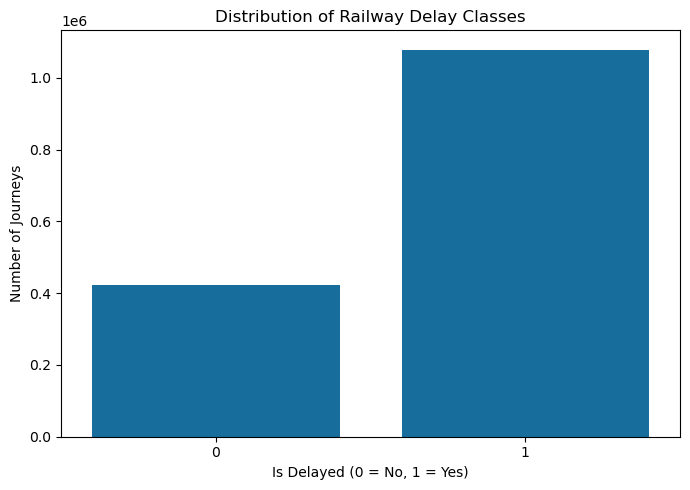

In [11]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x=TARGET)
plt.title("Distribution of Railway Delay Classes")
plt.xlabel("Is Delayed (0 = No, 1 = Yes)")
plt.ylabel("Number of Journeys")
plt.tight_layout()
plt.show()

## Observation: 
The supplied dataset contains 421,671 non-delayed journeys (28.11%) and 1,078,329 delayed journeys (71.89%). Therefore, the target is substantially imbalanced toward the delayed class. This class distribution should be considered when interpreting Accuracy, Precision, Recall, and Weighted F1-score.

## 6. Feature Type Identification

Features are classified according to their data type. The target, direct outcome/leakage variables, and identifier/date fields are separated before model training.

In [12]:
numeric_features_all = df.select_dtypes(include=np.number).columns.tolist()
categorical_features_all = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric columns:")
print(numeric_features_all)

print("\nCategorical columns:")
print(categorical_features_all)

Numeric columns:
['train_number', 'year', 'month', 'day_of_week', 'departure_hour', 'is_weekend', 'is_night_departure', 'is_peak_hour', 'is_festival_season', 'distance_km', 'num_scheduled_stops', 'scheduled_travel_hours', 'track_doubled', 'is_hdn_route', 'is_electrified', 'psr_count', 'is_circular_route', 'is_monsoon_season', 'is_fog_risk', 'fog_risk_score', 'zone_fog_index', 'zone_congestion_index', 'season_severity_score', 'loco_age_years', 'coach_age_years', 'has_lhb_coaches', 'is_rake_shared', 'maintenance_score', 'seat_utilisation_pct', 'is_overloaded', 'late_incoming_rake', 'is_special_train', 'route_historical_ontime_pct', 'delay_minutes', 'is_delayed']

Categorical columns:
['journey_id', 'train_type', 'departure_date', 'season', 'zone', 'zone_abbr', 'source_station_category', 'destination_station_category', 'traction_type', 'primary_delay_cause']


### Numerical Features

In [13]:
### Numerical Features
print("Numerical Features:")
print(numeric_features_all)

Numerical Features:
['train_number', 'year', 'month', 'day_of_week', 'departure_hour', 'is_weekend', 'is_night_departure', 'is_peak_hour', 'is_festival_season', 'distance_km', 'num_scheduled_stops', 'scheduled_travel_hours', 'track_doubled', 'is_hdn_route', 'is_electrified', 'psr_count', 'is_circular_route', 'is_monsoon_season', 'is_fog_risk', 'fog_risk_score', 'zone_fog_index', 'zone_congestion_index', 'season_severity_score', 'loco_age_years', 'coach_age_years', 'has_lhb_coaches', 'is_rake_shared', 'maintenance_score', 'seat_utilisation_pct', 'is_overloaded', 'late_incoming_rake', 'is_special_train', 'route_historical_ontime_pct', 'delay_minutes', 'is_delayed']


### Categorical Features

In [14]:
categorical_features_all

['journey_id',
 'train_type',
 'departure_date',
 'season',
 'zone',
 'zone_abbr',
 'source_station_category',
 'destination_station_category',
 'traction_type',
 'primary_delay_cause']

## 7. Exploratory Data Analysis

The EDA follows the same structure as the reference classification notebook: numerical distributions, categorical distributions, correlation analysis, feature-target relationships, and written observations.

Because the dataset has 1.5 million rows, plots use a reproducible sample for visualization. This sampling is only for visualization; it is not used to redefine the dataset.

In [15]:
EDA_SAMPLE_SIZE = min(10000, len(df))

eda_df = df.sample(
    n=EDA_SAMPLE_SIZE,
    random_state=RANDOM_STATE
).copy()

print("Rows used for EDA visualizations:", len(eda_df))

Rows used for EDA visualizations: 10000


### 7.1 Numerical Feature Distributions

Numerical feature distributions are examined using histograms. Direct outcome variables such as `delay_minutes` are excluded from predictive EDA because they are not valid predictors of the binary delay outcome.

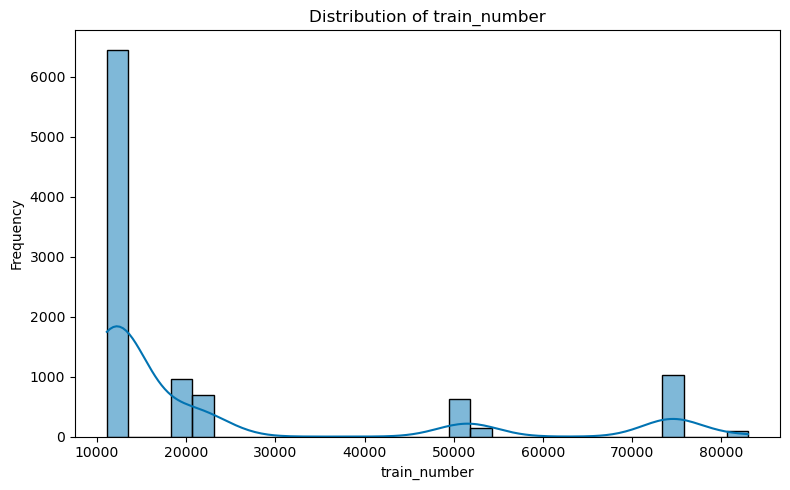

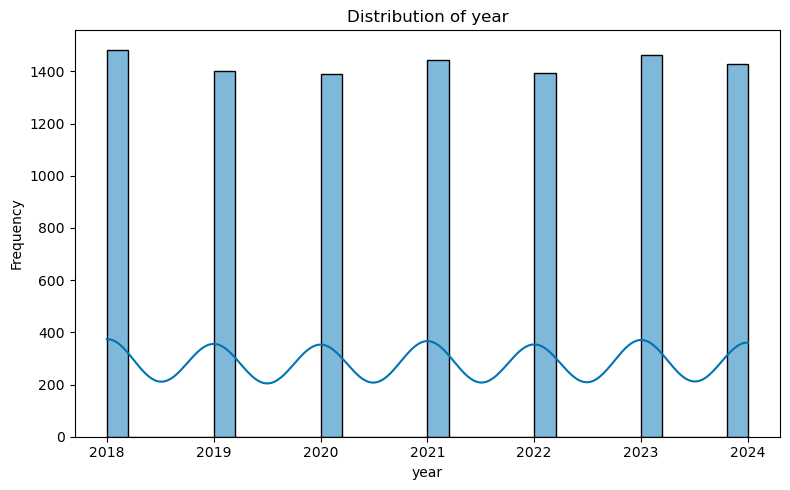

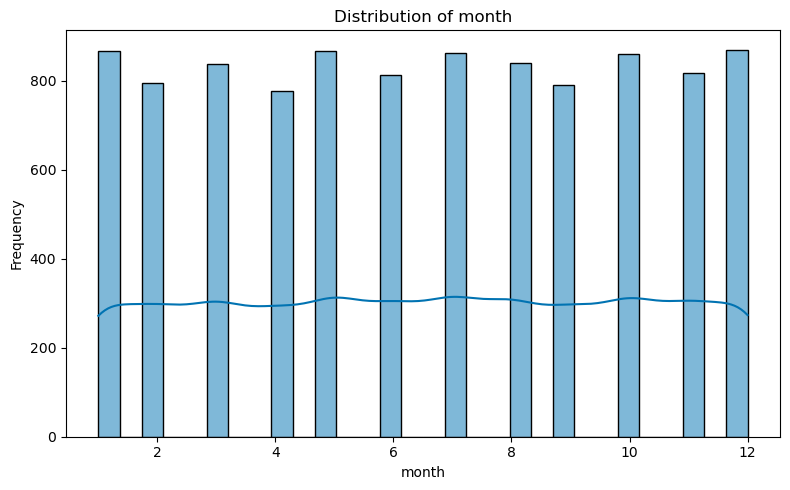

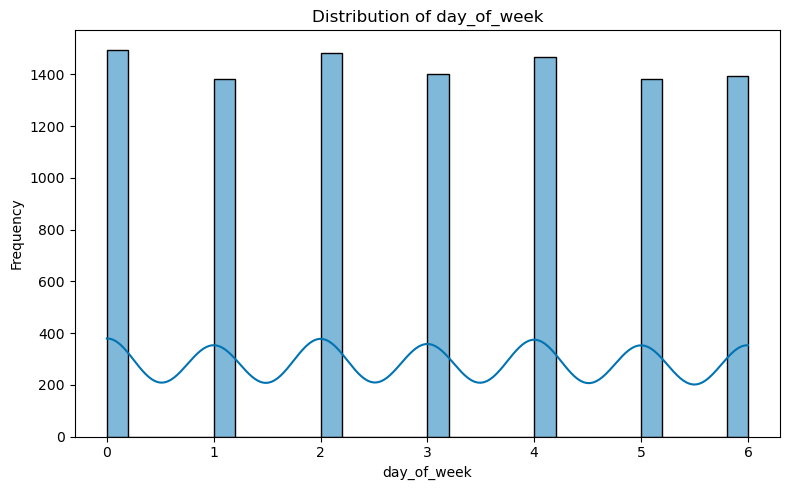

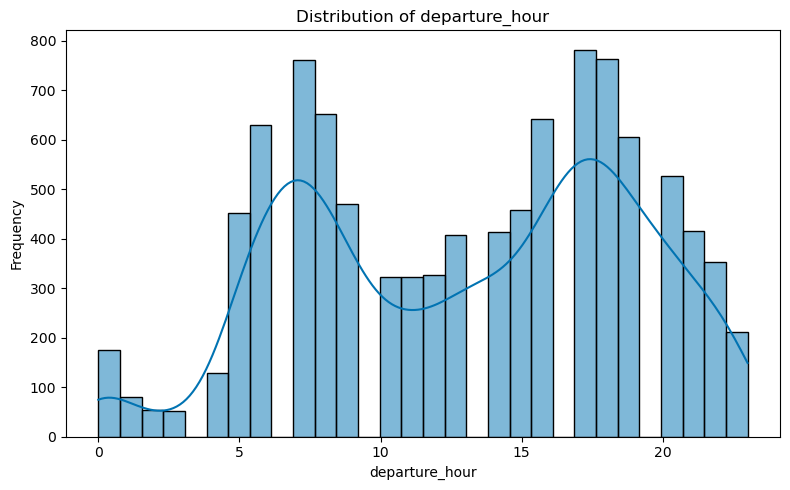

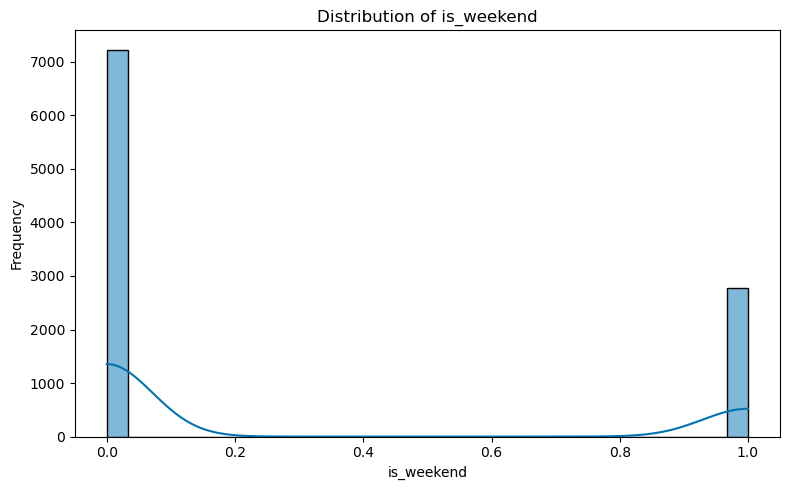

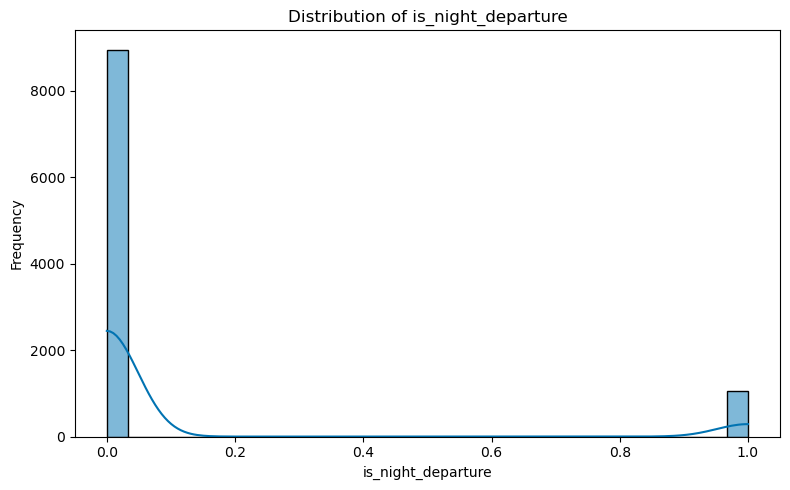

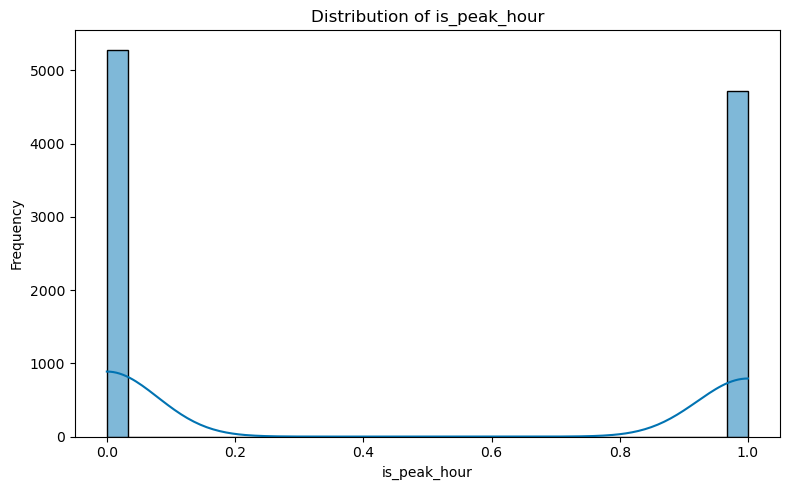

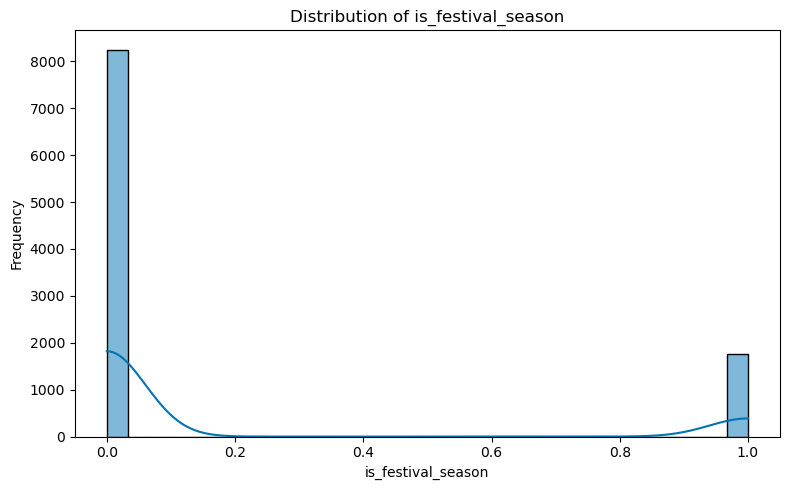

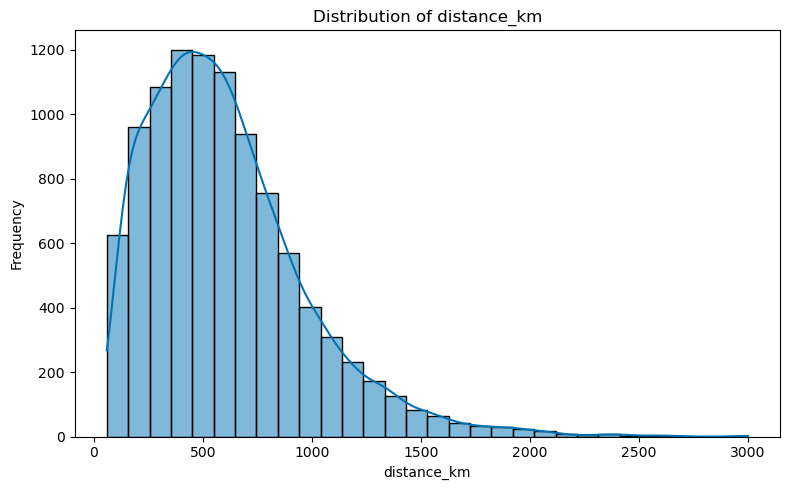

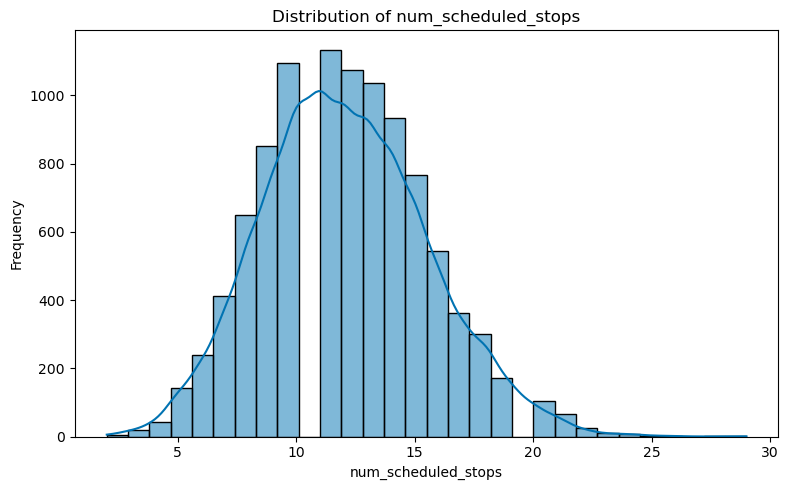

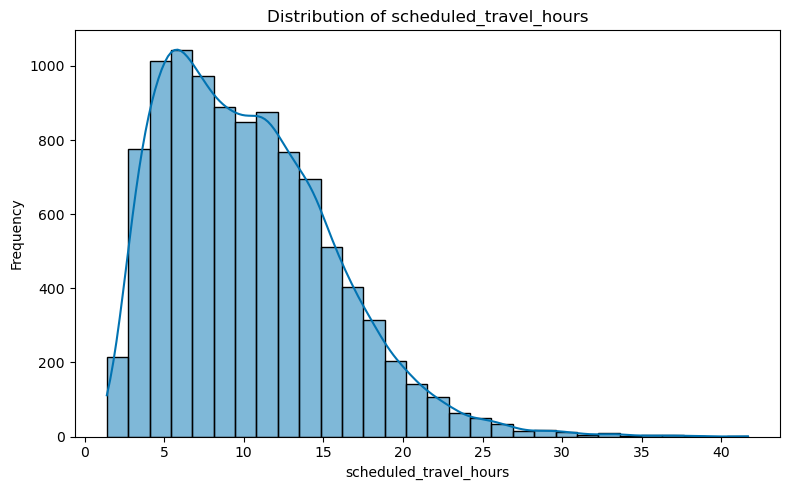

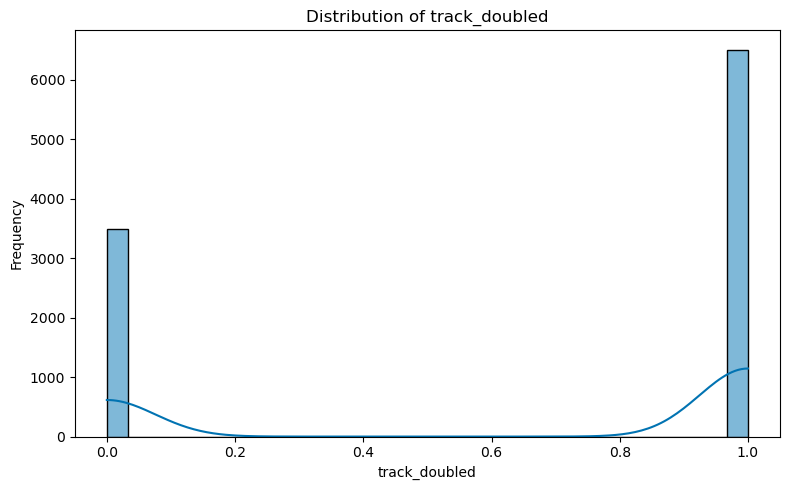

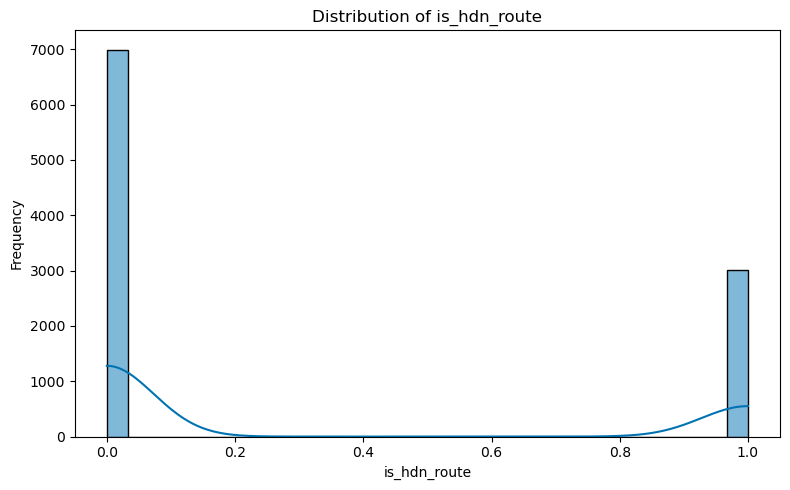

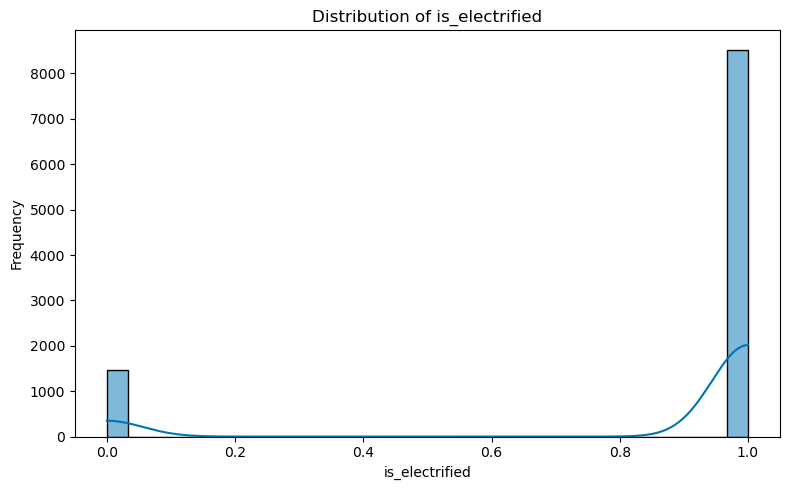

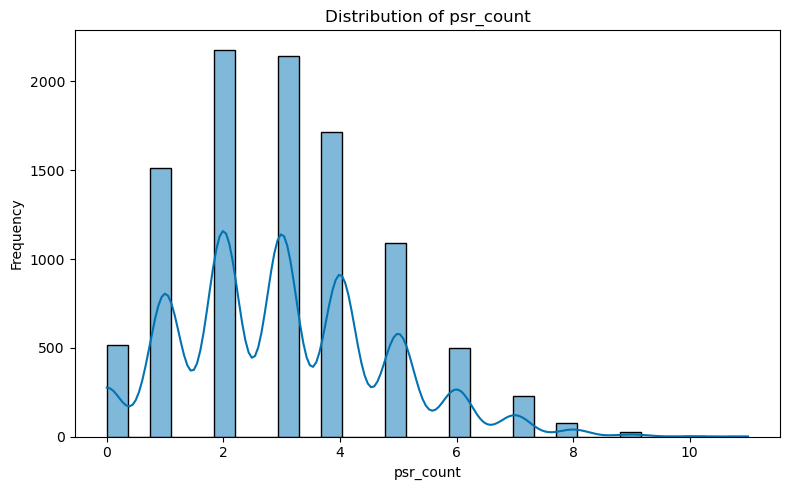

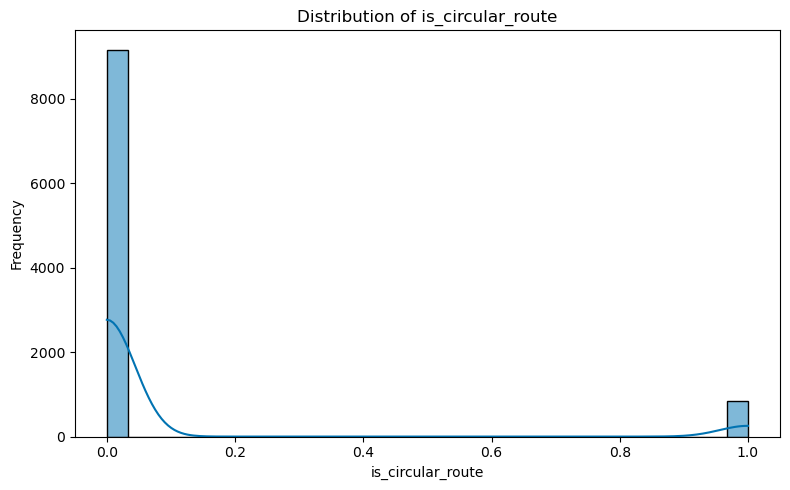

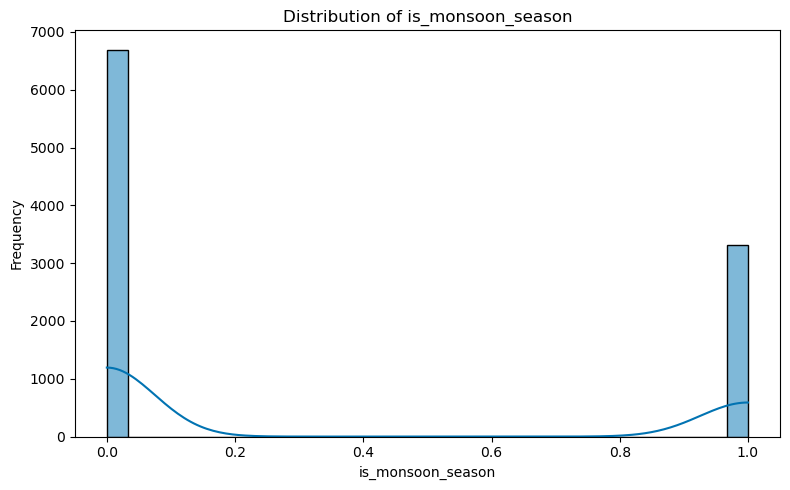

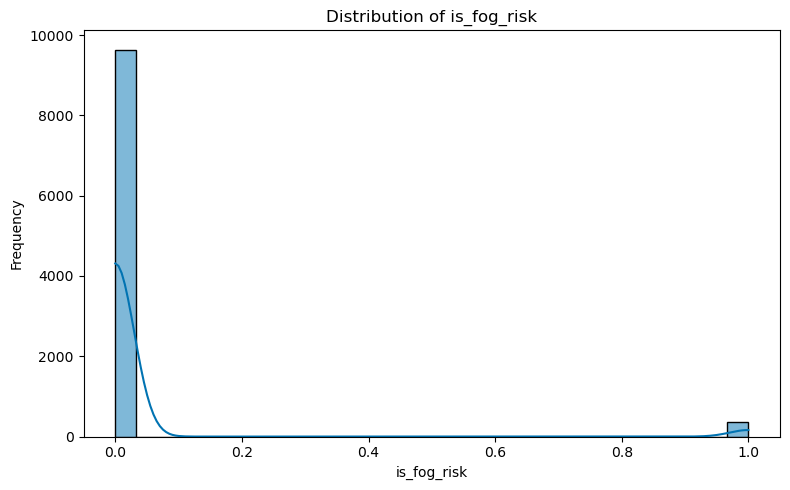

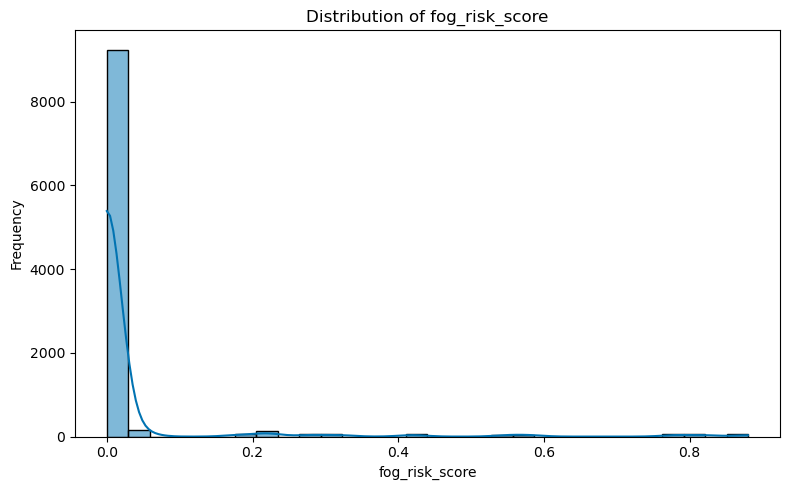

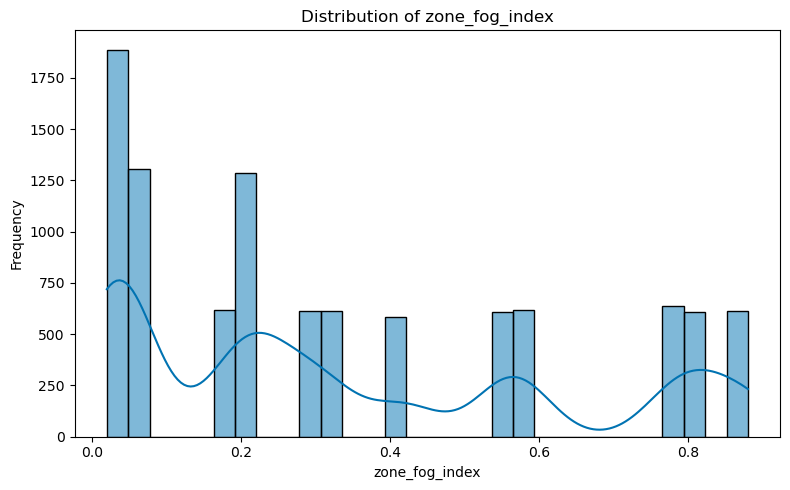

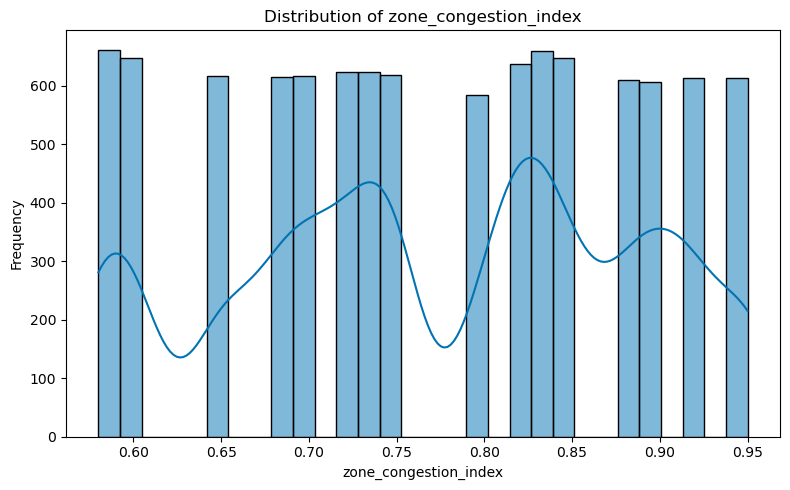

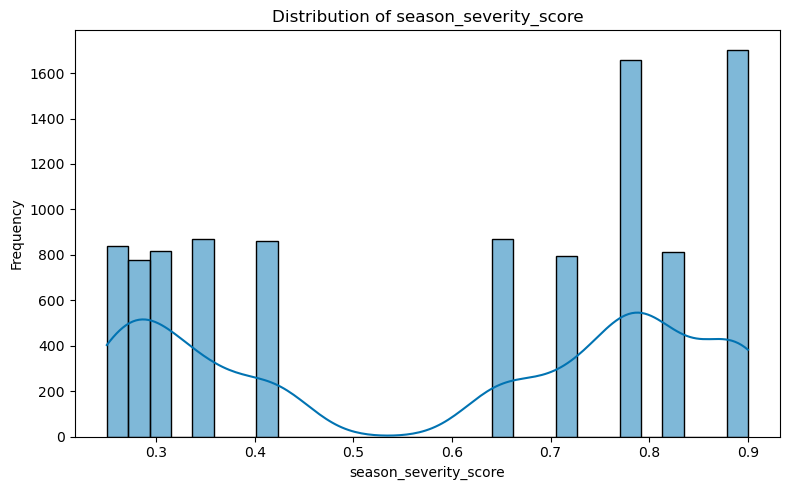

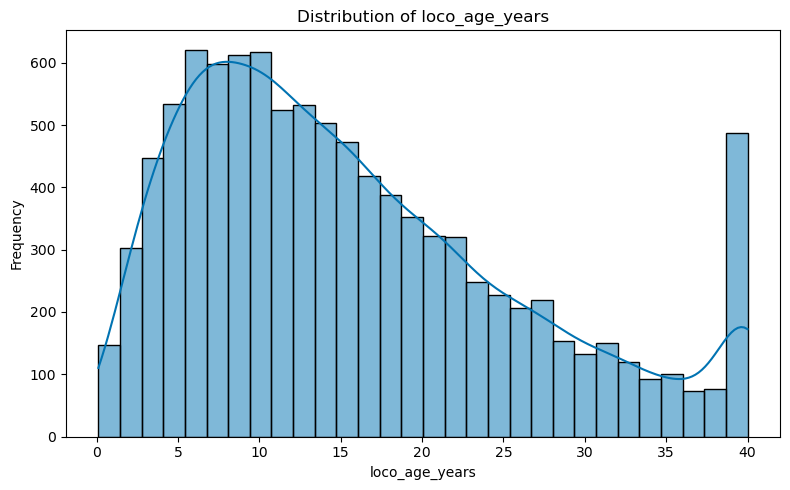

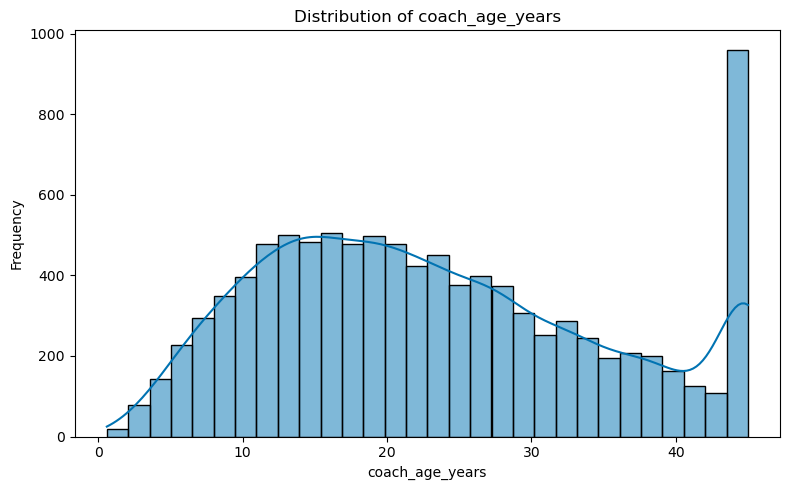

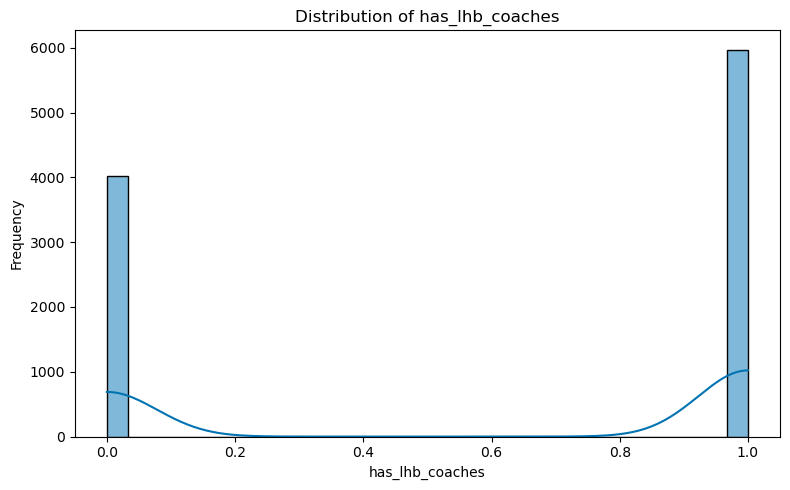

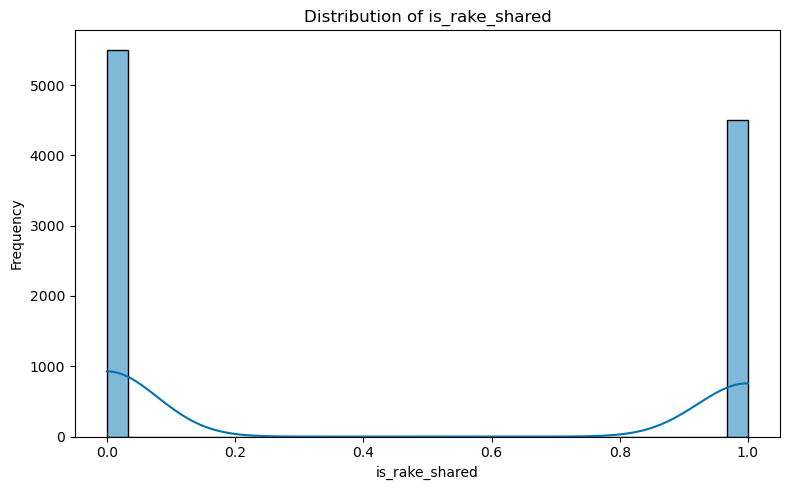

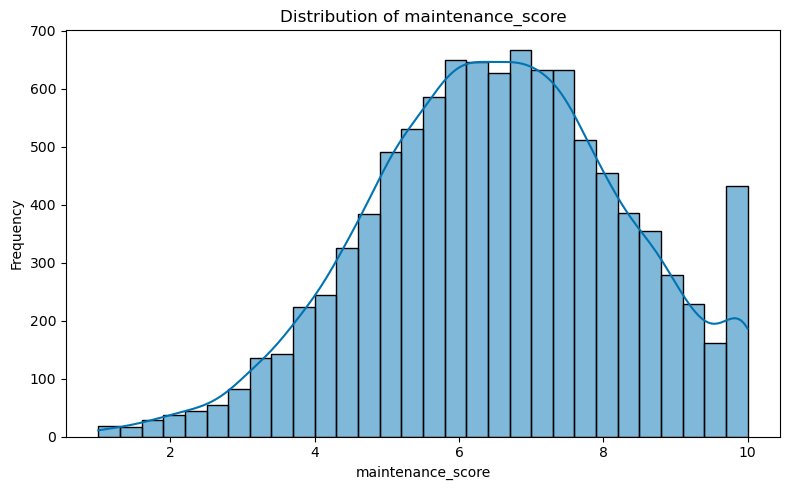

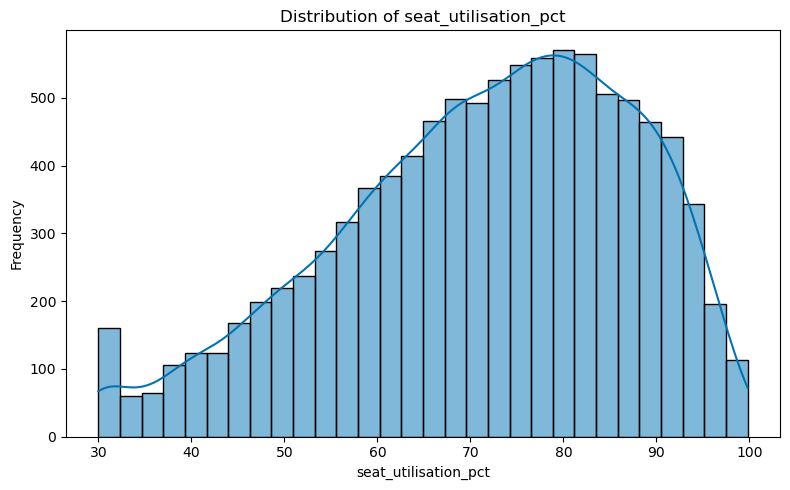

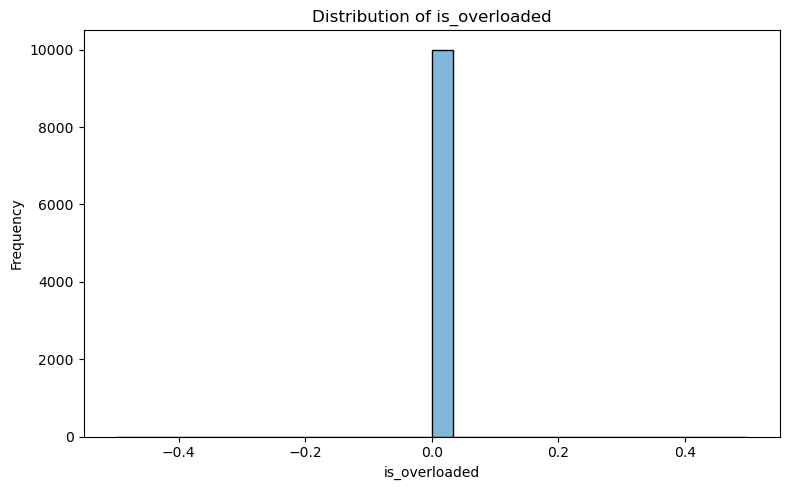

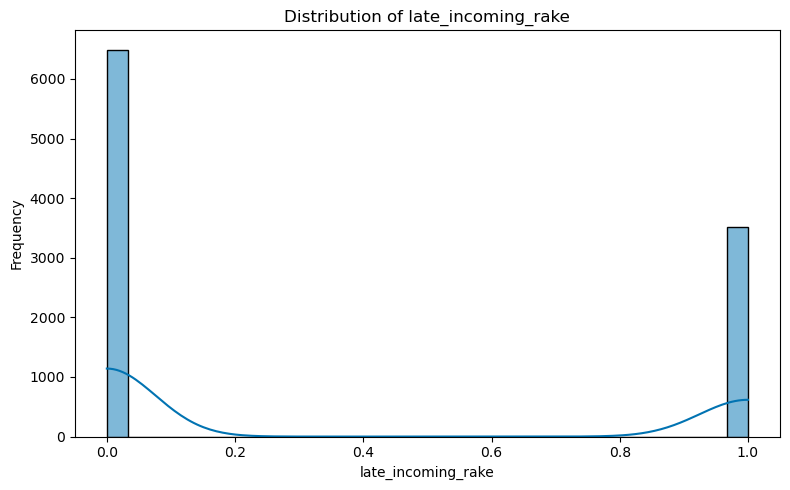

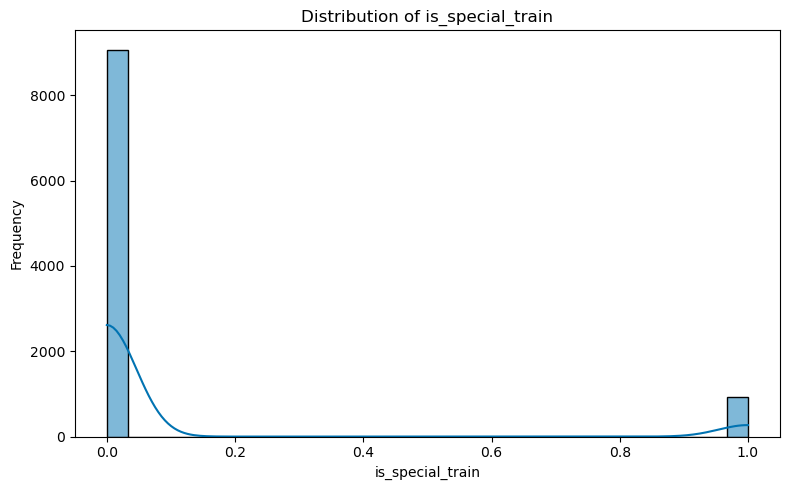

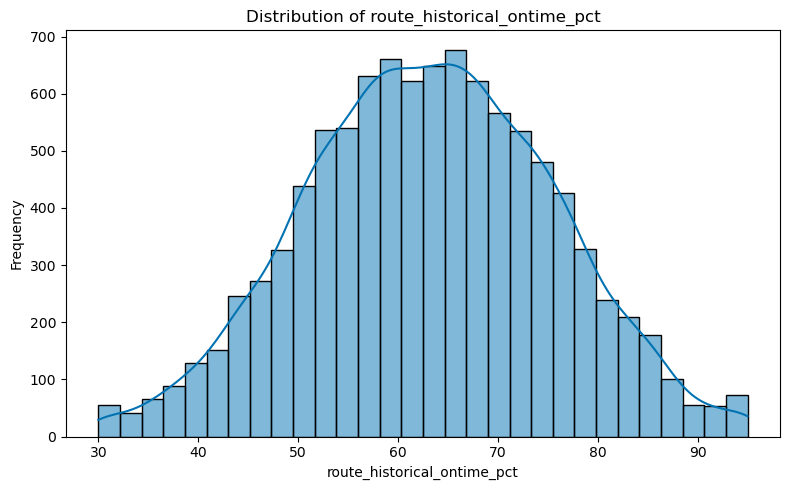

In [16]:
numeric_plot_features = [
    col for col in numeric_features_all
    if col not in [TARGET, "delay_minutes"]
]

for feature in numeric_plot_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=eda_df, x=feature, bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### 7.2 Categorical Feature Distributions

Categorical features are visualized with count plots. Very high-cardinality identifier/date fields are excluded from these plots to keep the EDA readable.

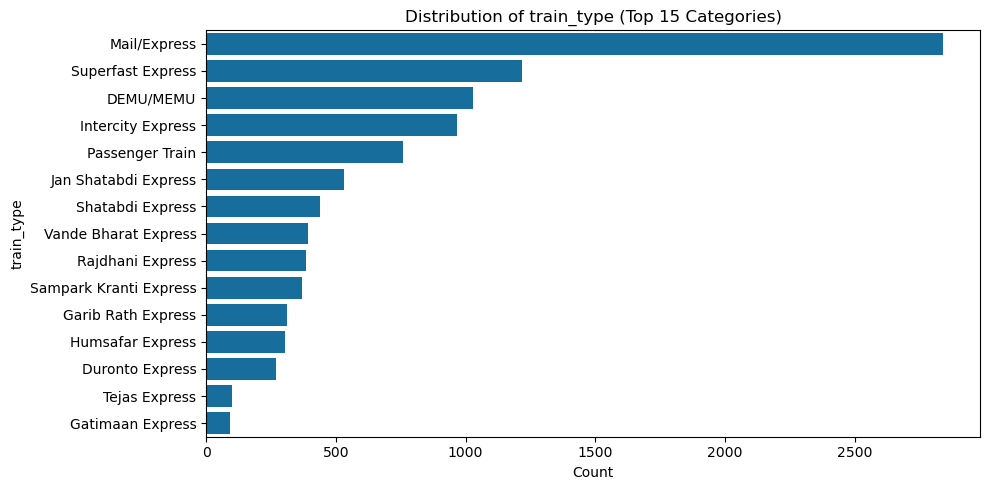

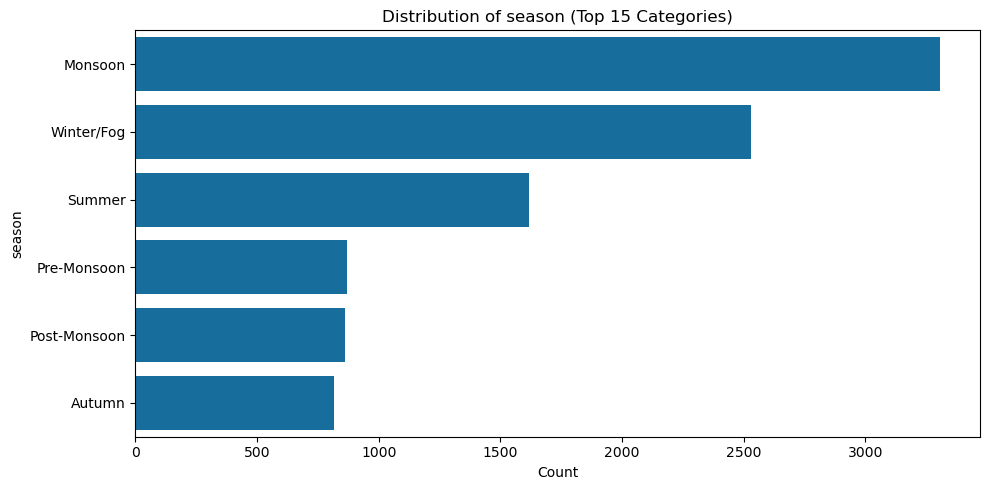

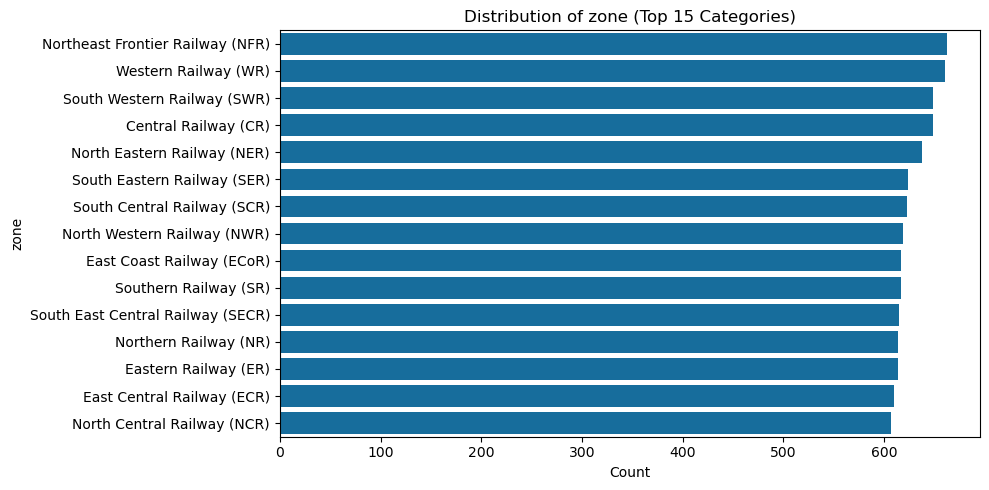

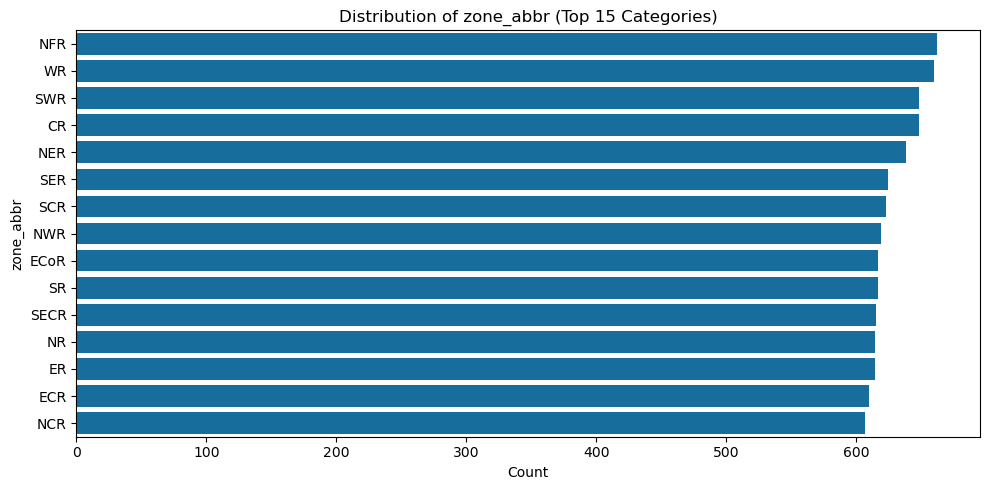

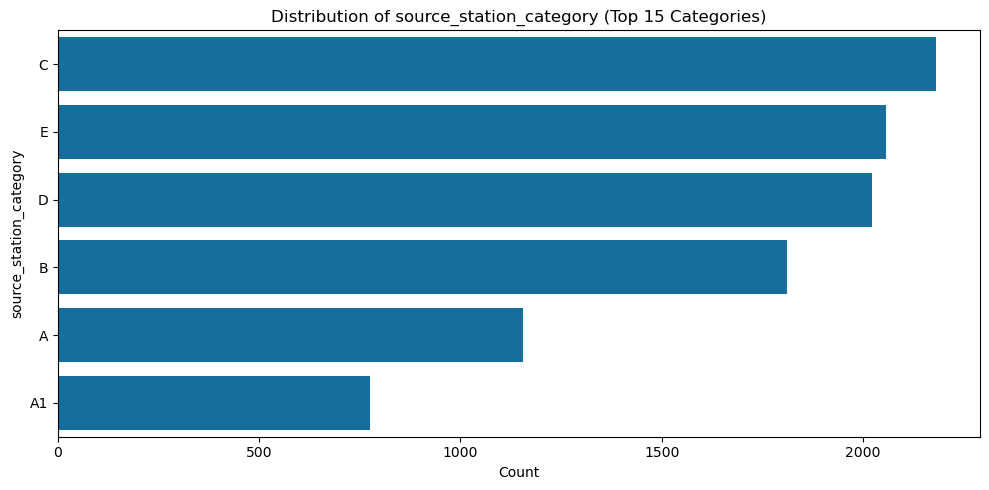

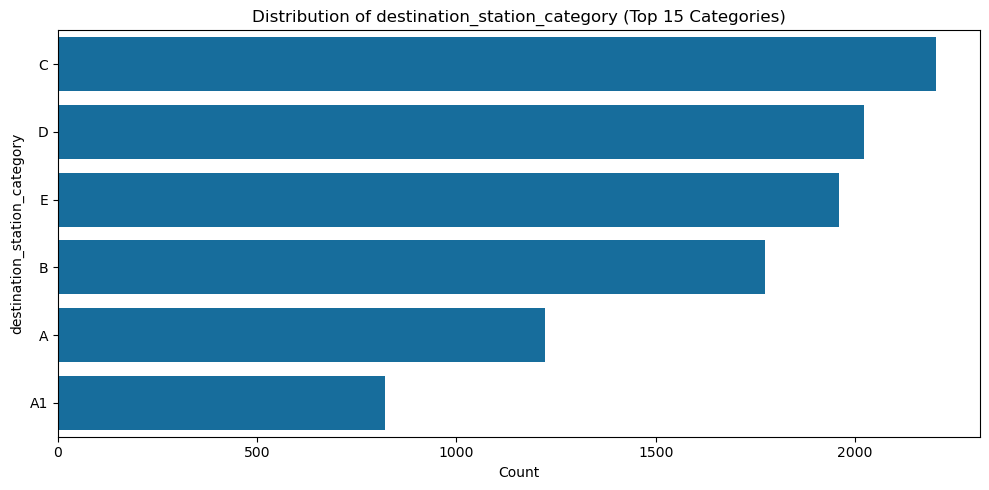

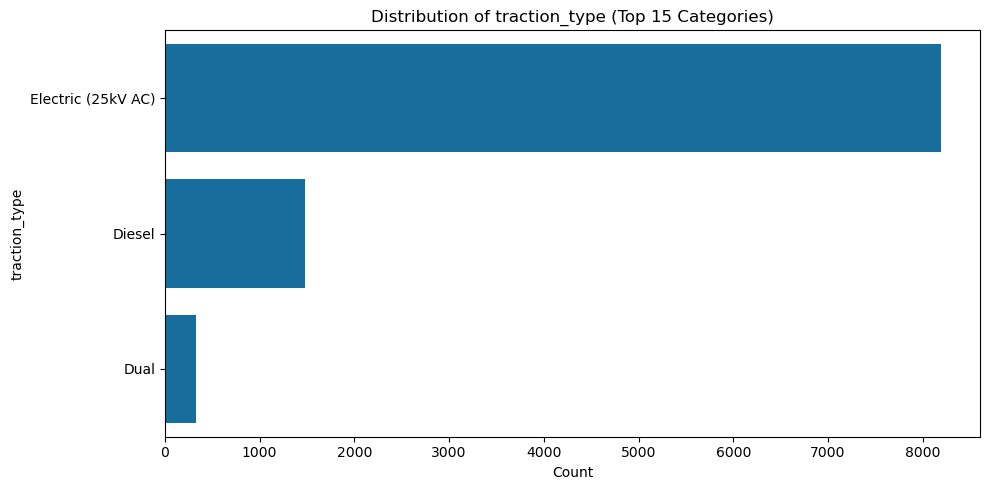

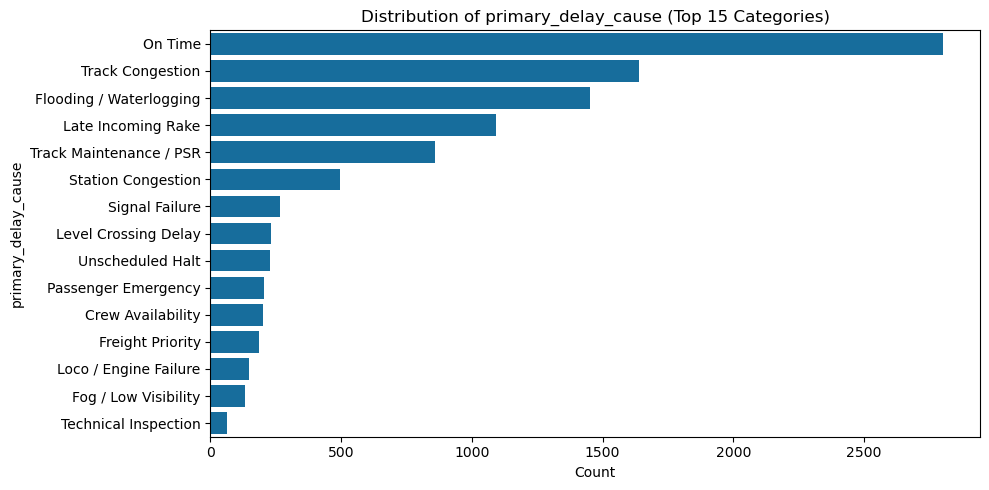

In [17]:
categorical_plot_features = [
    col for col in categorical_features_all
    if col not in ["journey_id", "departure_date"]
]

for feature in categorical_plot_features:
    plot_data = eda_df[feature].astype(str)
    top_categories = plot_data.value_counts().head(15).index

    plt.figure(figsize=(10, 5))
    sns.countplot(
        y=plot_data[plot_data.isin(top_categories)],
        order=top_categories
    )
    plt.title(f"Distribution of {feature} (Top 15 Categories)")
    plt.xlabel("Count")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

### 7.3 Correlation Heatmap

A correlation heatmap is used to examine relationships among numerical variables. `delay_minutes` is excluded because it directly contains the amount of delay and would be leakage for the `is_delayed` prediction task.

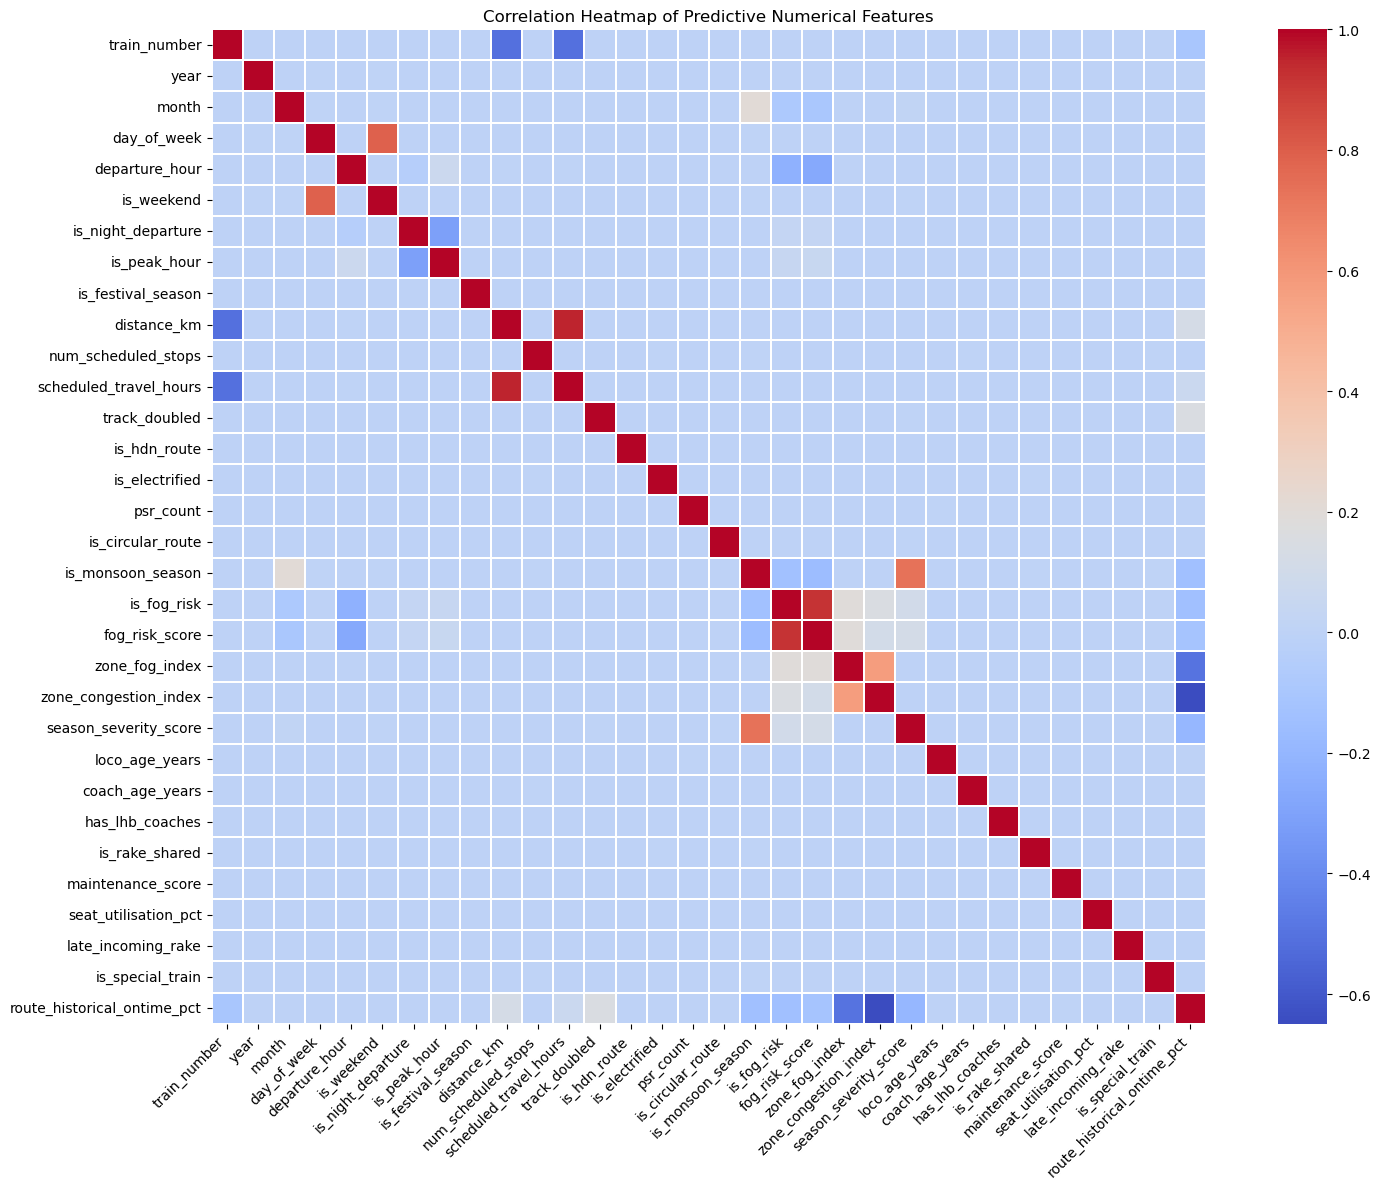

In [18]:
# Select numerical features excluding target and leakage variable
correlation_features = [
    col for col in numeric_features_all
    if col not in [TARGET, "delay_minutes"]
]

# Calculate correlation matrix
corr = df[correlation_features].corr()

# Remove features whose correlation values are completely NaN
# This prevents blank rows/columns from appearing in the heatmap.
valid_features = corr.columns[corr.notna().any(axis=0)].tolist()

corr = corr.loc[valid_features, valid_features]

# Plot correlation heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    linewidths=0.2,
    square=True
)

plt.title("Correlation Heatmap of Predictive Numerical Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.4 Feature–Target Relationships

Numerical features are correlated with the target to identify variables that may show stronger or weaker linear relationships with delay status. These correlations are descriptive only and do not replace model-based analysis.

In [19]:
target_correlations = (
    df[numeric_features_all]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .drop("delay_minutes", errors="ignore")
    .sort_values(key=abs, ascending=False)
)

display(target_correlations.to_frame("Correlation with is_delayed"))

,Correlation with is_delayed
route_historical_ontime_pct,-0.404034
season_severity_score,0.397367
is_monsoon_season,0.329669
zone_congestion_index,0.260235
late_incoming_rake,0.247020
zone_fog_index,0.176764
track_doubled,-0.172333
is_fog_risk,0.103657
fog_risk_score,0.099875
loco_age_years,0.087316


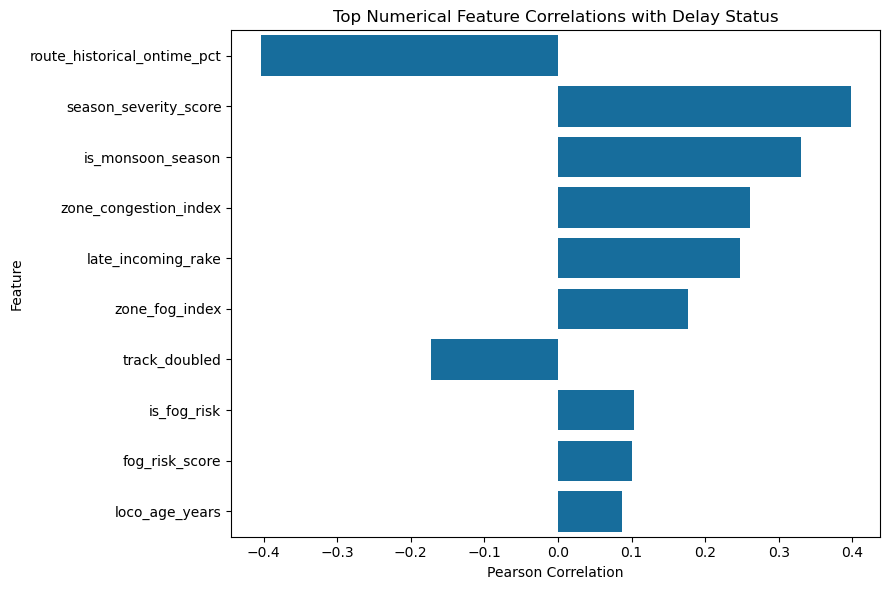

In [20]:
top_features = target_correlations.abs().head(10).index.tolist()

plt.figure(figsize=(9, 6))
sns.barplot(
    x=target_correlations.loc[top_features].values,
    y=top_features
)
plt.title("Top Numerical Feature Correlations with Delay Status")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 7.5 Feature–Target Scatter Plots

Two scatter plots are generated using the two numerical features with the strongest absolute target correlations. The target is used only for visualization here.

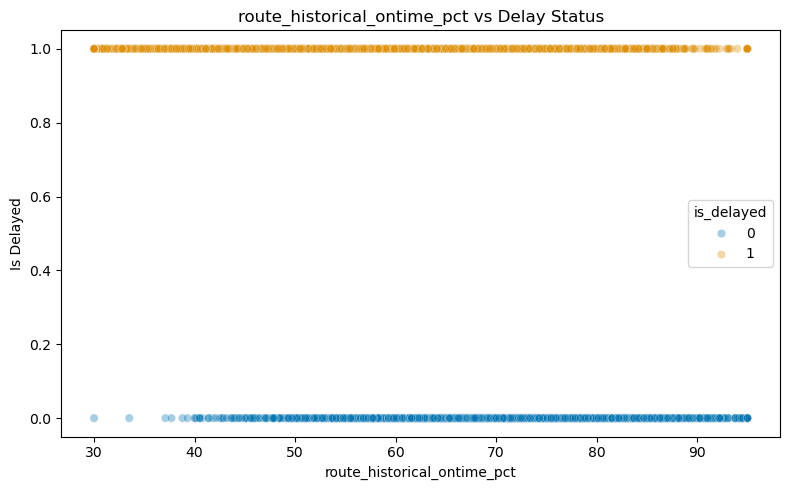

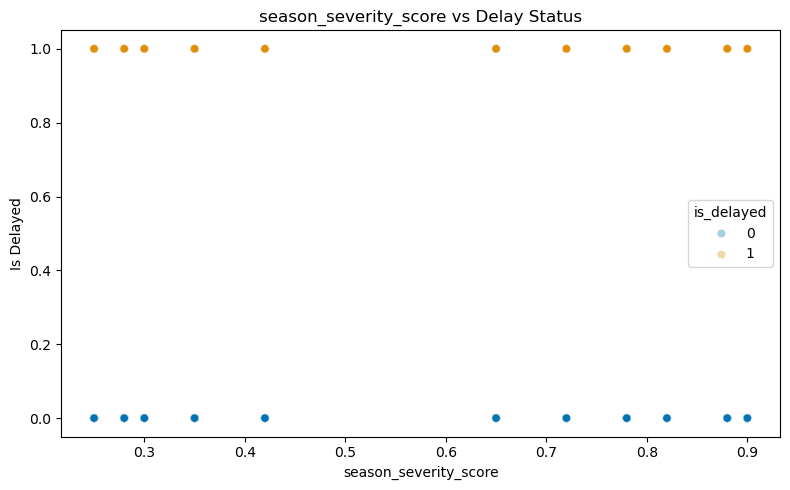

In [21]:
scatter_features = top_features[:2]

for feature in scatter_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=eda_df,
        x=feature,
        y=TARGET,
        hue=TARGET,
        alpha=0.35
    )
    plt.title(f"{feature} vs Delay Status")
    plt.xlabel(feature)
    plt.ylabel("Is Delayed")
    plt.tight_layout()
    plt.show()

### 7.6 EDA Observations

- The target distribution is imbalanced, with the delayed class representing 71.89% of the supplied records.
- The numerical distribution plots show the spread and range of the operational, infrastructure, weather-risk, and historical-performance variables.
- The categorical plots show the frequency of the available train, zone, route, traction, season, and other categorical groups.
- The correlation heatmap shows pairwise linear relationships among numerical predictive variables.
- The feature-target correlation analysis identifies numerical variables with comparatively stronger or weaker linear association with `is_delayed`.
- The scatter plots show the degree of overlap between delayed and non-delayed observations.

The exact visual interpretation of individual features should be confirmed from the generated plots during the review rather than inferred from code alone.

## 8. Data Preprocessing

The dataset is prepared for machine learning by checking duplicates and outliers, removing identifiers and outcome-leaking fields, creating an engineered feature, performing a stratified train-test split, and applying encoding/scaling inside model pipelines.

### 8.1 Duplicate Treatment

In [22]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found. No duplicate treatment was required.")

print("Dataset shape after duplicate treatment:", df.shape)

Duplicate rows: 0
No duplicate rows found. No duplicate treatment was required.
Dataset shape after duplicate treatment: (1500000, 45)


In [23]:
# Remove rows where the target label is missing.
# A missing target cannot be used for supervised classification.
missing_target_count = df[TARGET].isna().sum()
print(f"Missing {TARGET} values before removal: {missing_target_count}")

if missing_target_count > 0:
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)
    print(f"Removed {missing_target_count} rows with missing target values.")
else:
    print("No missing target values found.")

print("Dataset shape after target cleaning:", df.shape)
print("Remaining missing target values:", df[TARGET].isna().sum())


Missing is_delayed values before removal: 0
No missing target values found.
Dataset shape after target cleaning: (1500000, 45)
Remaining missing target values: 0


### 8.2 Outlier Analysis

Outliers are identified using the IQR method and visualized using boxplots. Statistical outliers are not automatically deleted because an extreme operational value can still represent a valid railway journey.

In [24]:
outlier_features = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in [TARGET, "delay_minutes"]
]

outlier_summary = []

for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count,
        "Outlier Percentage": 100 * count / len(df)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df.round(3))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,train_number,11900.00,22221.00,10321.00,-3581.500,37702.500,284320,18.955
1,year,2019.00,2023.00,4.00,2013.000,2029.000,0,0.000
2,month,4.00,10.00,6.00,-5.000,19.000,0,0.000
3,day_of_week,1.00,5.00,4.00,-5.000,11.000,0,0.000
4,departure_hour,8.00,18.00,10.00,-7.000,33.000,0,0.000
5,is_weekend,0.00,1.00,1.00,-1.500,2.500,0,0.000
6,is_night_departure,0.00,0.00,0.00,0.000,0.000,151015,10.068
7,is_peak_hour,0.00,1.00,1.00,-1.500,2.500,0,0.000
8,is_festival_season,0.00,0.00,0.00,0.000,0.000,270154,18.010
9,distance_km,342.00,792.00,450.00,-333.000,1467.000,47620,3.175


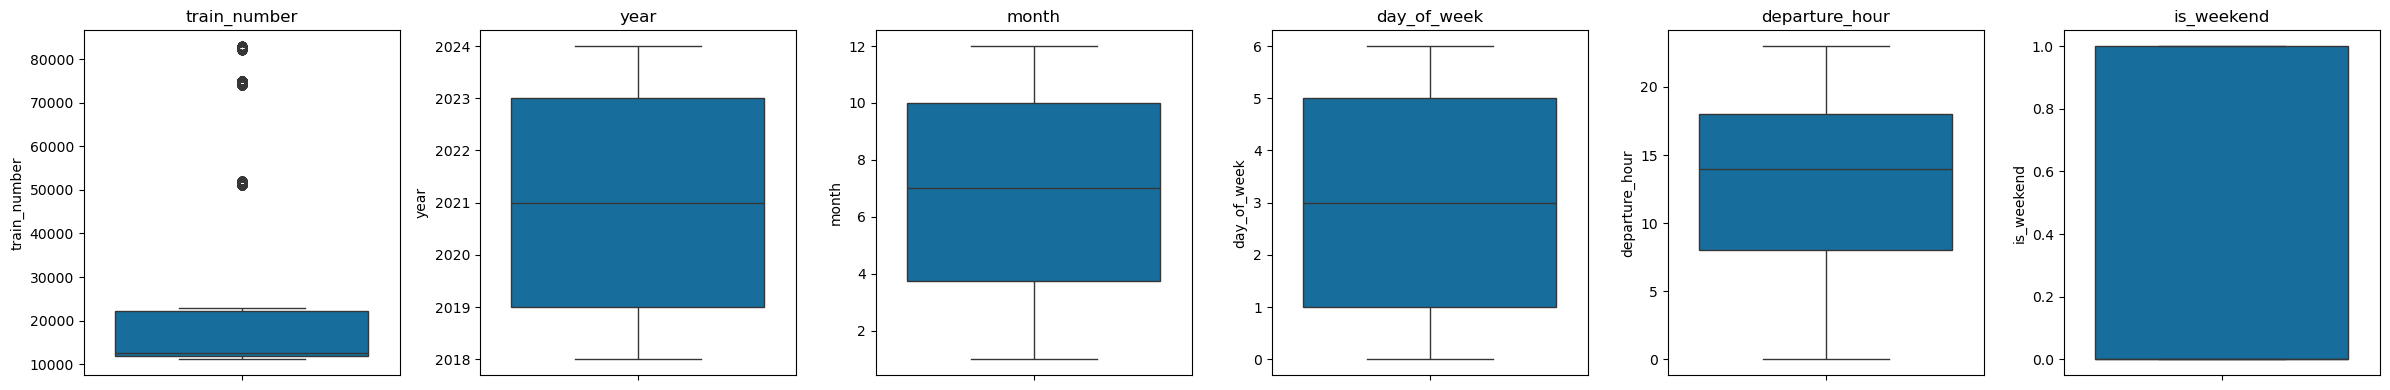

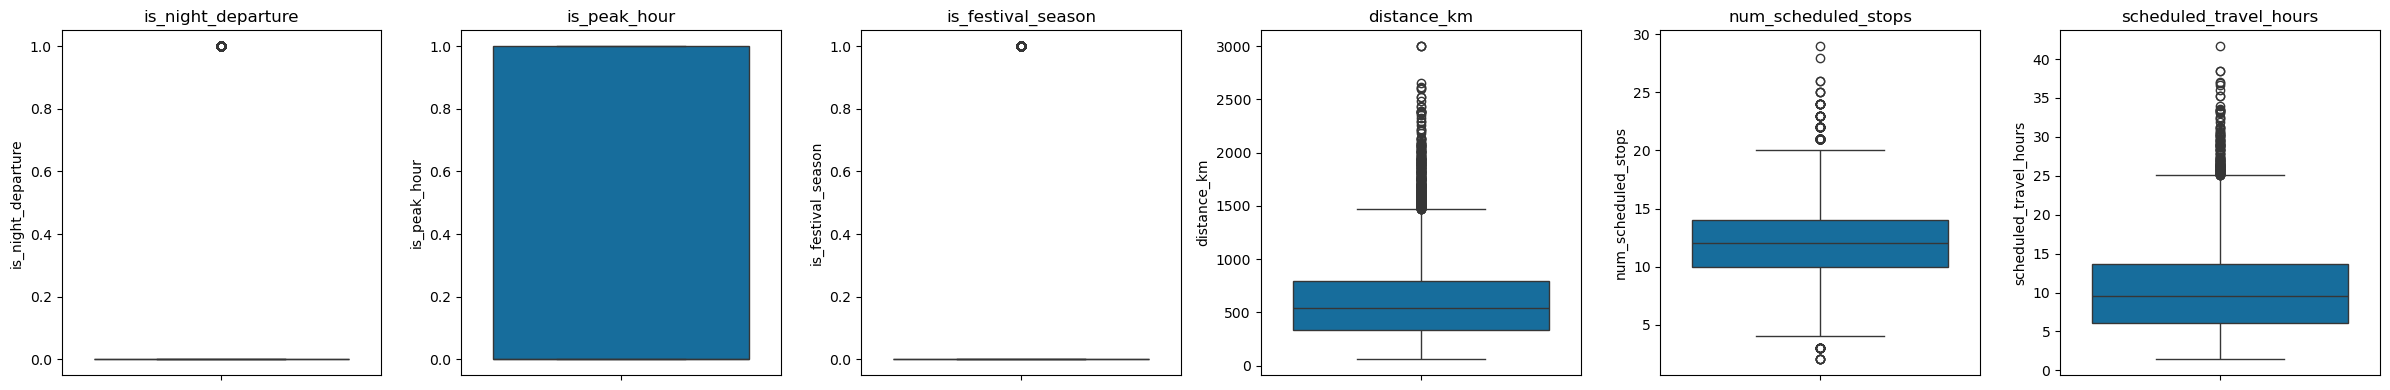

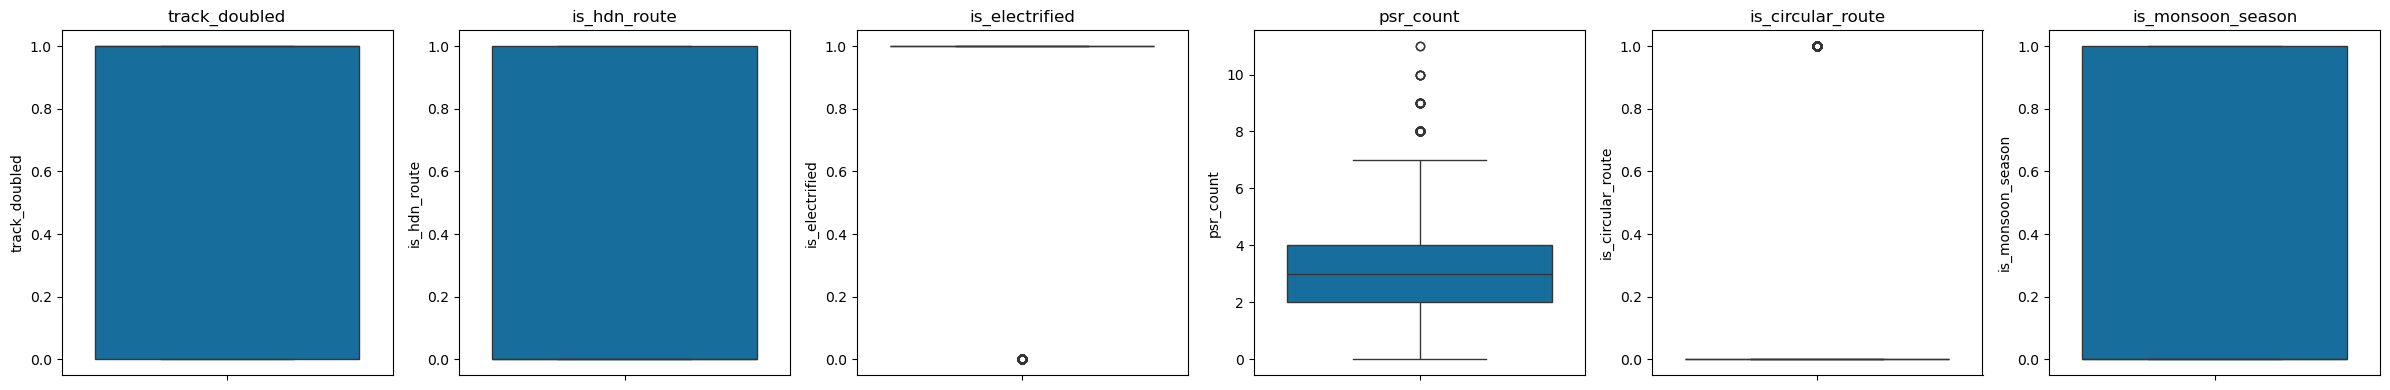

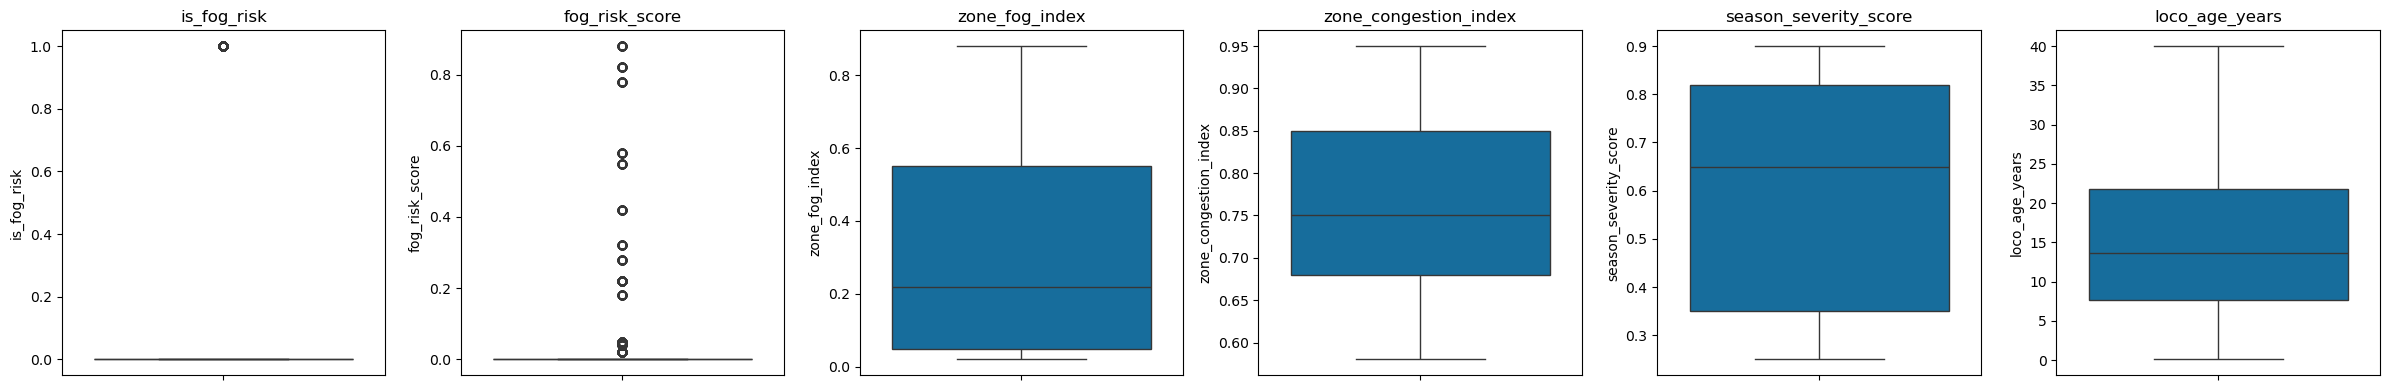

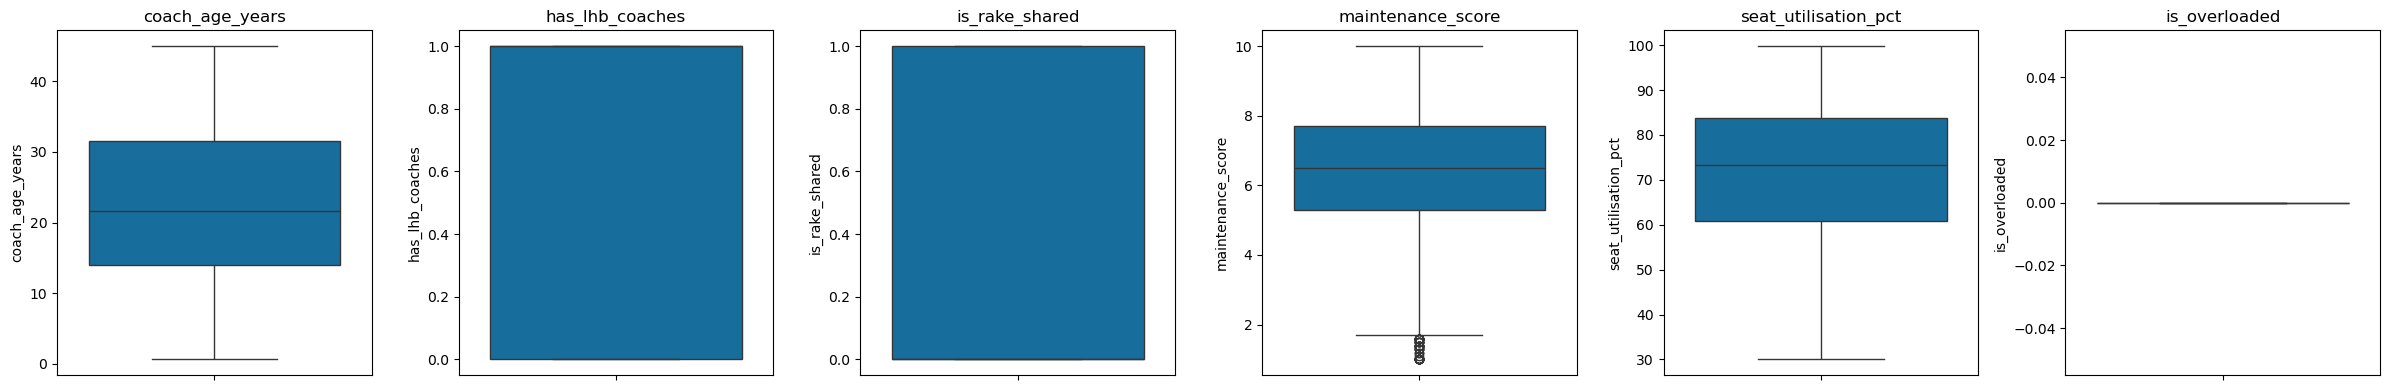

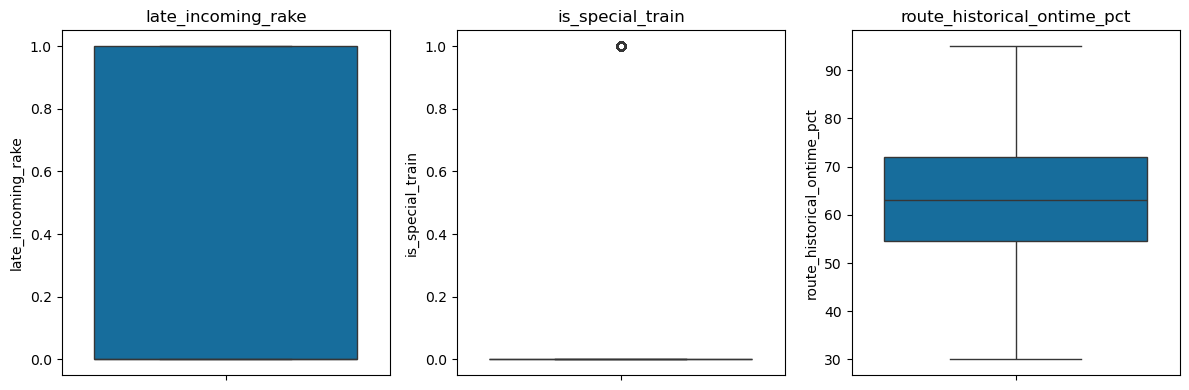

In [25]:
# Boxplots are shown in batches so the large feature set remains readable.
for start in range(0, len(outlier_features), 6):
    batch = outlier_features[start:start + 6]

    fig, axes = plt.subplots(
        1, len(batch),
        figsize=(4 * len(batch), 4)
    )

    if len(batch) == 1:
        axes = [axes]

    for ax, col in zip(axes, batch):
        sns.boxplot(y=eda_df[col], ax=ax)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

## Observation:
The IQR analysis identifies statistical outliers in some numerical variables. These observations are retained rather than automatically removed because the dataset represents real operational journeys and the IQR rule alone does not establish that an observation is invalid.

### 8.3 Leakage and Identifier Handling

For the classification task, variables that are only known after or because of the delay outcome must not be used as predictors.

In [26]:
LEAKAGE_COLUMNS = [
    "delay_minutes",
    "primary_delay_cause"
]

IDENTIFIER_OR_REDUNDANT_COLUMNS = [
    "journey_id",
    "departure_date"
]

DROP_COLUMNS = [
    col for col in LEAKAGE_COLUMNS + IDENTIFIER_OR_REDUNDANT_COLUMNS
    if col in df.columns
]

print("Columns excluded from predictive modelling:")
print(DROP_COLUMNS)

model_df = df.drop(columns=DROP_COLUMNS).copy()

print("Shape after leakage/identifier removal:", model_df.shape)

Columns excluded from predictive modelling:
['delay_minutes', 'primary_delay_cause', 'journey_id', 'departure_date']
Shape after leakage/identifier removal: (1500000, 41)


`delay_minutes` directly measures the amount of delay and therefore reveals the target outcome. `primary_delay_cause` describes the observed reason associated with the journey's delay and is also unavailable as a legitimate pre-outcome predictor. `journey_id` is an identifier, while `departure_date` is excluded as a raw date field because its useful information is already represented by engineered calendar fields such as year, month, day of week, season, and departure hour.

### 8.4 Feature Engineering

In [27]:
# Planned average speed in km/h.
# Replace zero denominators with NaN before calculating.
model_df["scheduled_speed_kmph"] = (
    model_df["distance_km"] /
    model_df["scheduled_travel_hours"].replace(0, np.nan)
)

model_df["scheduled_speed_kmph"] = (
    model_df["scheduled_speed_kmph"]
    .replace([np.inf, -np.inf], np.nan)
)

display(
    model_df[
        ["distance_km", "scheduled_travel_hours", "scheduled_speed_kmph"]
    ].head()
)

,distance_km,scheduled_travel_hours,scheduled_speed_kmph
0,620,10.33,60.019361
1,1423,23.72,59.991568
2,449,4.73,94.926004
3,1443,22.20,65.000000
4,219,5.21,42.034549


## Observation / justification: 
`scheduled_speed_kmph` combines route distance and scheduled travel time into a single operational measure of the planned average journey speed. This can provide the classifiers with a compact representation of route-time intensity instead of requiring the model to infer the ratio from two separate variables.

### 8.5 Train-Test Split

The data is split using an 80:20 ratio with stratification. The same split is used as the foundation for all five Part-A algorithms.

In [28]:
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().mul(100).rename("Percentage"))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).sort_index().mul(100).rename("Percentage"))

Training shape: (1200000, 41)
Testing shape: (300000, 41)

Training target distribution:


is_delayed
0    28.111417
1    71.888583
Name: Percentage, dtype: float64


Testing target distribution:


is_delayed
0    28.111333
1    71.888667
Name: Percentage, dtype: float64

## Observation:
An 80:20 stratified split is used so that the class proportions remain comparable between the training and held-out test portions.

### 8.6 Encoding and Scaling

Categorical variables are one-hot encoded and numerical variables are standardized. The preprocessing is placed inside each model's pipeline so it is fitted using the training data rather than the held-out evaluation data.

`journey_id` and the raw `departure_date` are already removed, while leakage variables are excluded before the split.

In [29]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical predictive features:", len(numeric_features))
print(numeric_features)

print("\nCategorical predictive features:", len(categorical_features))
print(categorical_features)

# Impute missing feature values inside the preprocessing pipeline.
# Numerical features use the median; categorical features use the most frequent value.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("\nPreprocessor created successfully.")


Numerical predictive features: 34
['train_number', 'year', 'month', 'day_of_week', 'departure_hour', 'is_weekend', 'is_night_departure', 'is_peak_hour', 'is_festival_season', 'distance_km', 'num_scheduled_stops', 'scheduled_travel_hours', 'track_doubled', 'is_hdn_route', 'is_electrified', 'psr_count', 'is_circular_route', 'is_monsoon_season', 'is_fog_risk', 'fog_risk_score', 'zone_fog_index', 'zone_congestion_index', 'season_severity_score', 'loco_age_years', 'coach_age_years', 'has_lhb_coaches', 'is_rake_shared', 'maintenance_score', 'seat_utilisation_pct', 'is_overloaded', 'late_incoming_rake', 'is_special_train', 'route_historical_ontime_pct', 'scheduled_speed_kmph']

Categorical predictive features: 7
['train_type', 'season', 'zone', 'zone_abbr', 'source_station_category', 'destination_station_category', 'traction_type']

Preprocessor created successfully.


## 9. Classification — Part A

The five Review-1 algorithms are implemented. All models use the same cleaned feature set, the same stratified train/test split, and the same common evaluation subset.

### Computational handling for this 1.5-million-row dataset

The full 80:20 split is retained. A fixed stratified modelling subset is drawn from the training portion for the computationally expensive KNN/SVC and GridSearchCV steps. A fixed stratified evaluation subset is drawn from the held-out test portion and is reused for **every model**, so the preliminary comparison remains directly comparable.

In [30]:
MODEL_TRAIN_SIZE = min(30000, len(X_train))
EVAL_TEST_SIZE = min(30000, len(X_test))

X_model_train, _, y_model_train, _ = train_test_split(
    X_train,
    y_train,
    train_size=MODEL_TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train
)

X_eval, _, y_eval, _ = train_test_split(
    X_test,
    y_test,
    train_size=EVAL_TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_test
)

print("Common model-training subset:", X_model_train.shape)
print("Common evaluation subset:", X_eval.shape)

print("\nModel-training target distribution:")
display(y_model_train.value_counts(normalize=True).sort_index().mul(100).rename("Percentage"))

print("\nEvaluation target distribution:")
display(y_eval.value_counts(normalize=True).sort_index().mul(100).rename("Percentage"))

Common model-training subset: (30000, 41)
Common evaluation subset: (30000, 41)

Model-training target distribution:


is_delayed
0    28.11
1    71.89
Name: Percentage, dtype: float64


Evaluation target distribution:


is_delayed
0    28.11
1    71.89
Name: Percentage, dtype: float64

### 9.1 Logistic Regression

In [31]:
log_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver="saga",
        n_jobs=-1
    ))
])

log_reg.fit(X_model_train, y_model_train)

print("Logistic Regression trained successfully.")

# Predictions on evaluation data
log_pred = log_reg.predict(X_eval)
log_prob = log_reg.predict_proba(X_eval)[:, 1]

# Display evaluation metrics
print("\nLogistic Regression Performance:")
print(f"Accuracy  : {accuracy_score(y_eval, log_pred):.4f}")
print(f"Precision : {precision_score(y_eval, log_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_eval, log_pred, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_eval, log_pred, average='weighted', zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_eval, log_prob):.4f}")

Logistic Regression trained successfully.

Logistic Regression Performance:
Accuracy  : 0.8609
Precision : 0.8881
Recall    : 0.9228
F1 Score  : 0.8586
ROC-AUC   : 0.9220


### 9.2 K-Nearest Neighbors

In [32]:
# Train K-Nearest Neighbors
knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ))
])

knn.fit(X_model_train, y_model_train)

print("KNN trained successfully.")

# Predictions on evaluation data
knn_pred = knn.predict(X_eval)
knn_prob = knn.predict_proba(X_eval)[:, 1]

# Display evaluation metrics
print("\nKNN Performance:")
print(f"Accuracy  : {accuracy_score(y_eval, knn_pred):.4f}")
print(f"Precision : {precision_score(y_eval, knn_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_eval, knn_pred, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_eval, knn_pred, average='weighted', zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_eval, knn_prob):.4f}")

KNN trained successfully.

KNN Performance:
Accuracy  : 0.8083
Precision : 0.8549
Recall    : 0.8832
F1 Score  : 0.8056
ROC-AUC   : 0.8424


## 9.3 Gaussian Naive Bayes

Gaussian Naive Bayes requires a dense feature matrix. Since one-hot encoding can produce many columns, a compact TruncatedSVD representation is used before GaussianNB. The one-hot encoder and SVD remain inside the pipeline to preserve leakage-safe preprocessing.

In [33]:
# Gaussian Naive Bayes Preprocessor
nb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Gaussian Naive Bayes Pipeline
nb = Pipeline([
    ("preprocessor", nb_preprocessor),
    ("svd", TruncatedSVD(
        n_components=30,
        random_state=RANDOM_STATE
    )),
    ("classifier", GaussianNB())
])

# Train the model
nb.fit(X_model_train, y_model_train)

print("Gaussian Naive Bayes trained successfully.")

# Predictions on evaluation data
nb_pred = nb.predict(X_eval)
nb_prob = nb.predict_proba(X_eval)[:, 1]

# Display evaluation metrics
print("\nGaussian Naive Bayes Performance:")
print(f"Accuracy  : {accuracy_score(y_eval, nb_pred):.4f}")
print(f"Precision : {precision_score(y_eval, nb_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_eval, nb_pred, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_eval, nb_pred, average='weighted', zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_eval, nb_prob):.4f}")

Gaussian Naive Bayes trained successfully.

Gaussian Naive Bayes Performance:
Accuracy  : 0.8290
Precision : 0.8830
Recall    : 0.8785
F1 Score  : 0.8293
ROC-AUC   : 0.8840


### 9.4 Decision Tree Classifier

In [34]:
# Decision Tree Classifier
dtree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=8
    ))
])

# Train the model
dtree.fit(X_model_train, y_model_train)

print("Decision Tree trained successfully.")

# Predictions on evaluation data
dt_pred = dtree.predict(X_eval)
dt_prob = dtree.predict_proba(X_eval)[:, 1]

# Display evaluation metrics
print("\nDecision Tree Performance:")
print(f"Accuracy  : {accuracy_score(y_eval, dt_pred):.4f}")
print(f"Precision : {precision_score(y_eval, dt_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_eval, dt_pred, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_eval, dt_pred, average='weighted', zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_eval, dt_prob):.4f}")

Decision Tree trained successfully.

Decision Tree Performance:
Accuracy  : 0.8289
Precision : 0.8629
Recall    : 0.9061
F1 Score  : 0.8252
ROC-AUC   : 0.8837


### 9.5 Support Vector Classifier

SVC is computationally expensive on very large datasets. The fixed modelling subset is therefore used, followed by TruncatedSVD to reduce the high-dimensional one-hot encoded representation before SVC.

In [35]:
# Support Vector Classifier
svm = Pipeline([
    ("preprocessor", preprocessor),
    ("svd", TruncatedSVD(
        n_components=20,
        random_state=RANDOM_STATE
    )),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        probability=False,
        random_state=RANDOM_STATE
    ))
])

# Train the model
svm.fit(X_model_train, y_model_train)

print("Support Vector Classifier trained successfully.")

# Predictions on evaluation data
svm_pred = svm.predict(X_eval)

# Use decision scores for ROC-AUC
svm_score = svm.decision_function(X_eval)

# Display evaluation metrics
print("\nSupport Vector Classifier Performance:")
print(f"Accuracy  : {accuracy_score(y_eval, svm_pred):.4f}")
print(f"Precision : {precision_score(y_eval, svm_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_eval, svm_pred, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_eval, svm_pred, average='weighted', zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_eval, svm_score):.4f}")

Support Vector Classifier trained successfully.

Support Vector Classifier Performance:
Accuracy  : 0.8438
Precision : 0.8656
Recall    : 0.9266
F1 Score  : 0.8388
ROC-AUC   : 0.8954


In [36]:
trained_models = {
    "Logistic Regression": log_reg,
    "KNN": knn,
    "Naive Bayes": nb,
    "Decision Tree": dtree,
    "SVM": svm
}

print("Models available:")
for name in trained_models:
    print("-", name)

Models available:
- Logistic Regression
- KNN
- Naive Bayes
- Decision Tree
- SVM


## 10. Model Evaluation

The trained models are evaluated on the **same common evaluation subset** using Accuracy, Precision, Recall, Weighted F1-score, ROC-AUC, and Confusion Matrix.

For this binary target, ROC-AUC is calculated from the probability of class `1`.

In [37]:
eval_results = []
prediction_store = {}

for name, model in trained_models.items():

    # Predictions
    preds = model.predict(X_eval)

    # Get scores/probabilities for ROC-AUC
    if name == "SVM":
        scores = model.decision_function(X_eval)
    else:
        scores = model.predict_proba(X_eval)[:, 1]

    # Store predictions and scores
    prediction_store[name] = {
        "predictions": preds,
        "probabilities": scores
    }

    # Calculate evaluation metrics
    eval_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_eval, preds),
        "Precision": precision_score(
            y_eval, preds, zero_division=0
        ),
        "Recall": recall_score(
            y_eval, preds, zero_division=0
        ),
        "F1 (weighted)": f1_score(
            y_eval,
            preds,
            average="weighted",
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_eval, scores
        )
    })

# Create results table
results_df = pd.DataFrame(eval_results)

display(results_df.round(3))

,Model,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
0,Logistic Regression,0.861,0.888,0.923,0.859,0.922
1,KNN,0.808,0.855,0.883,0.806,0.842
2,Naive Bayes,0.829,0.883,0.879,0.829,0.884
3,Decision Tree,0.829,0.863,0.906,0.825,0.884
4,SVM,0.844,0.866,0.927,0.839,0.895


In [38]:
print("Classification reports on the common evaluation subset:")

for name, model in trained_models.items():
    print(f"\n{name}")
    print(
        classification_report(
            y_eval,
            prediction_store[name]["predictions"],
            digits=3,
            zero_division=0
        )
    )

Classification reports on the common evaluation subset:

Logistic Regression
              precision    recall  f1-score   support

           0      0.781     0.702     0.740      8433
           1      0.888     0.923     0.905     21567

    accuracy                          0.861     30000
   macro avg      0.834     0.813     0.822     30000
weighted avg      0.858     0.861     0.859     30000


KNN
              precision    recall  f1-score   support

           0      0.674     0.617     0.644      8433
           1      0.855     0.883     0.869     21567

    accuracy                          0.808     30000
   macro avg      0.764     0.750     0.756     30000
weighted avg      0.804     0.808     0.806     30000


Naive Bayes
              precision    recall  f1-score   support

           0      0.693     0.702     0.698      8433
           1      0.883     0.879     0.881     21567

    accuracy                          0.829     30000
   macro avg      0.788     0.790

**Observation:** The evaluation table provides a common baseline for the five Part-A classifiers. Record the metric differences shown by the actual notebook output during the review. Because the target is imbalanced, Accuracy should be interpreted together with Precision, Recall, Weighted F1-score, and ROC-AUC rather than in isolation.

## 11. Preliminary Model Comparison

In [39]:
comparison_df = (
    pd.DataFrame(eval_results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(comparison_df.round(3))

,Model,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
0,Logistic Regression,0.861,0.888,0.923,0.859,0.922
1,SVM,0.844,0.866,0.927,0.839,0.895
2,Naive Bayes,0.829,0.883,0.879,0.829,0.884
3,Decision Tree,0.829,0.863,0.906,0.825,0.884
4,KNN,0.808,0.855,0.883,0.806,0.842


**Observation:** The five Part-A models produce different Accuracy, Precision, Recall, Weighted F1-score, and ROC-AUC values. The ordering should be taken directly from the generated comparison table rather than written in advance.

## 12. Confusion Matrices

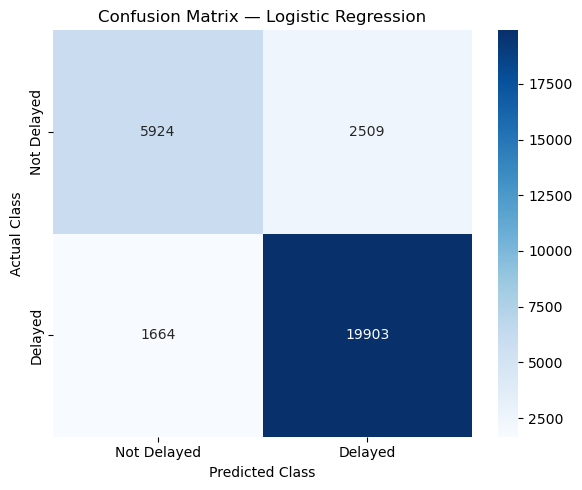

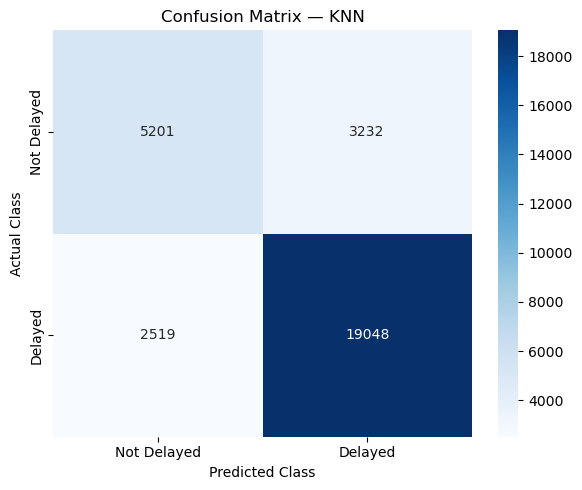

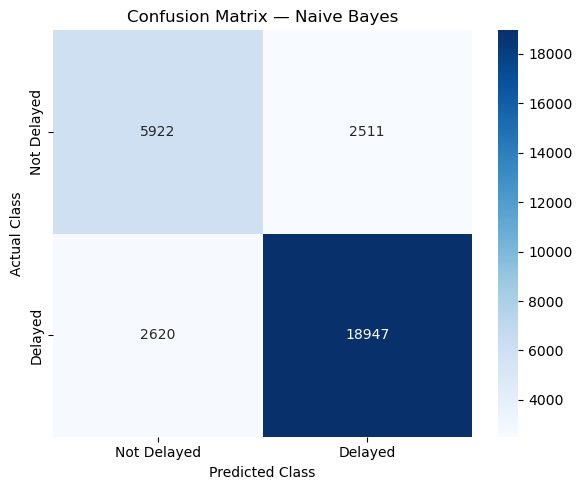

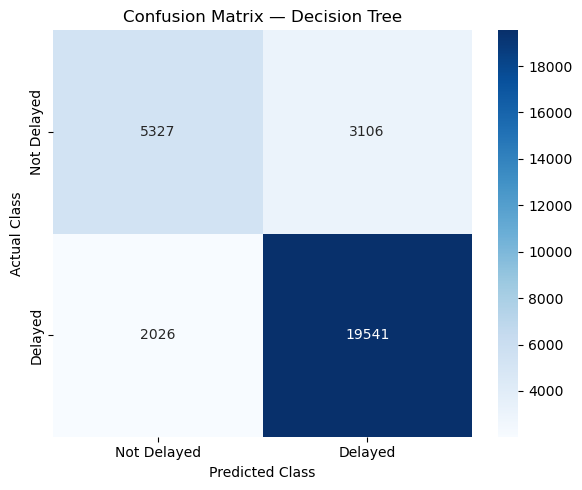

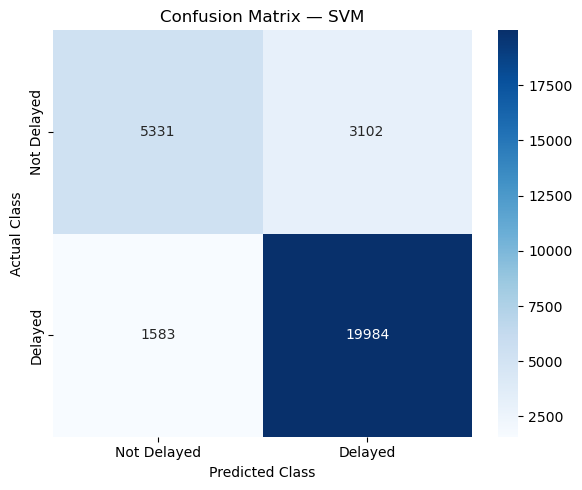

In [40]:
for name in trained_models:
    preds = prediction_store[name]["predictions"]

    cm = confusion_matrix(y_eval, preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Delayed", "Delayed"],
        yticklabels=["Not Delayed", "Delayed"]
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

## 13. ROC Curve Comparison

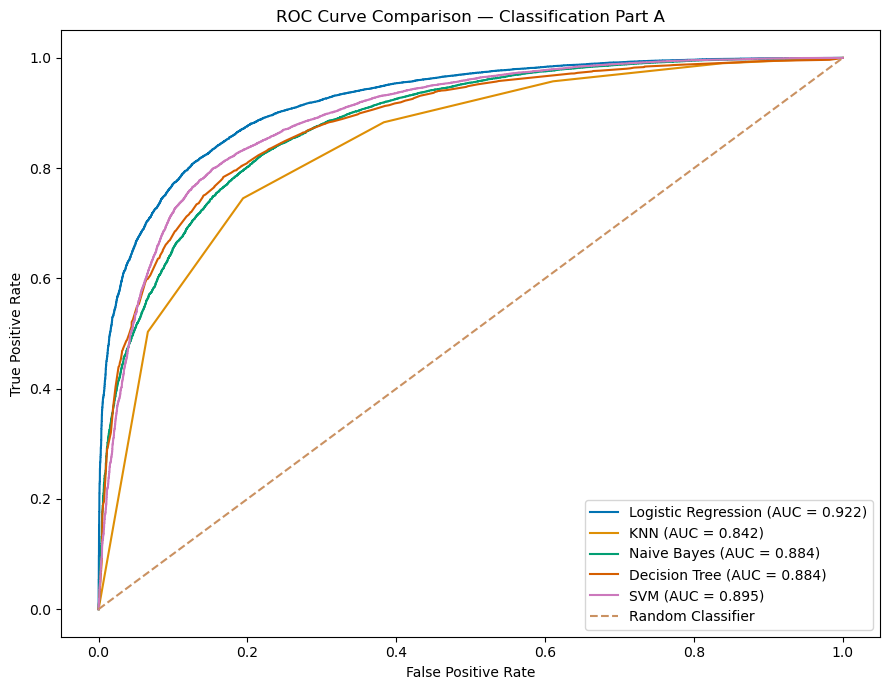

In [41]:
plt.figure(figsize=(9, 7))

for name in trained_models:
    probs = prediction_store[name]["probabilities"]

    fpr, tpr, _ = roc_curve(y_eval, probs)
    auc_score = roc_auc_score(y_eval, probs)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison — Classification Part A")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Classification Metrics Comparison

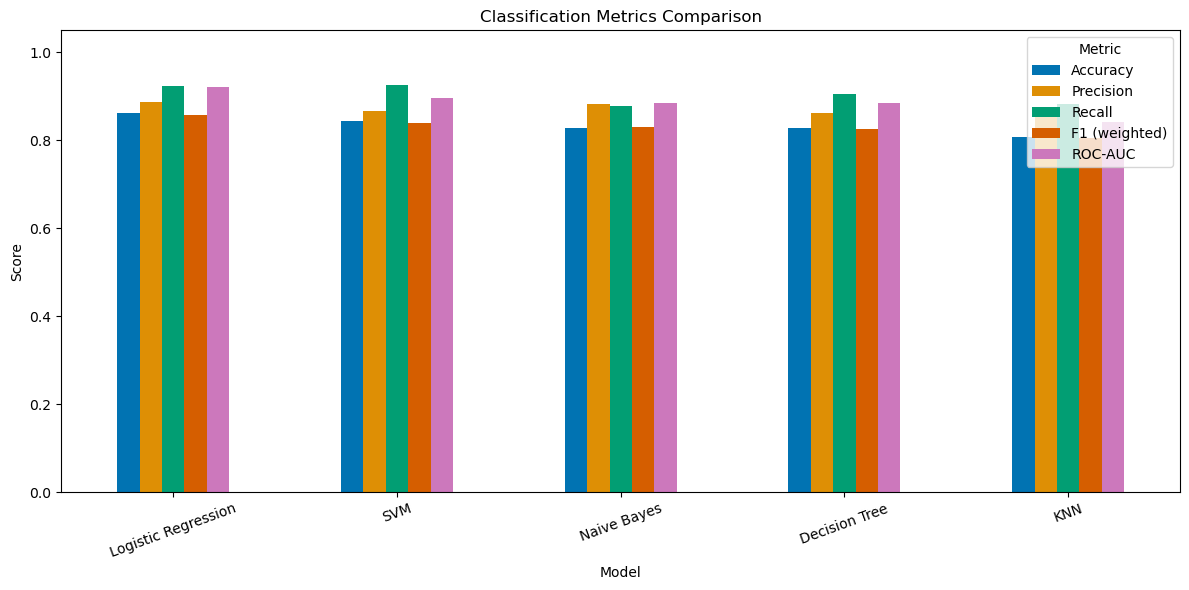

In [42]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 (weighted)",
    "ROC-AUC"
]

plot_df = comparison_df.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Metrics Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 15. Algorithm-Specific Analysis

### 15.1 Logistic Regression — Coefficient / Odds Interpretation

The Logistic Regression coefficients are examined to understand how the transformed features affect the log-odds of the delayed class.

For a coefficient `β`, the odds ratio is `exp(β)`. An odds ratio above 1 indicates increased odds for the delayed class for a one-unit increase in the transformed feature, while an odds ratio below 1 indicates decreased odds, holding the other model variables constant.

In [43]:
feature_names = log_reg.named_steps["preprocessor"].get_feature_names_out()
coefficients = log_reg.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients)
}).sort_values("Odds Ratio", ascending=False)

display(coef_df.round(3))

,Feature,Coefficient,Odds Ratio
22,num__season_severity_score,1.280,3.596
30,num__late_incoming_rake,1.150,3.157
21,num__zone_congestion_index,0.618,1.855
41,cat__train_type_Passenger Train,0.558,1.746
40,cat__train_type_Mail/Express,0.509,1.664
...,...,...,...
43,cat__train_type_Sampark Kranti Express,-0.490,0.613
52,cat__season_Winter/Fog,-0.567,0.567
12,num__track_doubled,-0.715,0.489
32,num__route_historical_ontime_pct,-0.761,0.467


**Observation:** The coefficient table provides an interpretable view of the Logistic Regression model. Positive coefficients increase the model's log-odds for the delayed class, while negative coefficients decrease them. One-hot encoded categorical features are interpreted relative to their reference category.

### 15.2 K-Nearest Neighbors — Hyperparameter Tuning

The number of neighbors and distance metric are tuned using five-fold cross-validation.

In [44]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_jobs=-1
    ))
])

knn_param_grid = {
    "classifier__n_neighbors": range(1, 21),
    "classifier__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid.fit(X_model_train, y_model_train)

print("Best KNN parameters:", knn_grid.best_params_)
print("Best 5-fold CV accuracy:", knn_grid.best_score_)

best_knn = knn_grid.best_estimator_

Best KNN parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 20}
Best 5-fold CV accuracy: 0.8312666666666667


**Observation:** The best `k` and distance metric must be recorded from the actual GridSearchCV output. The tuning objective is five-fold cross-validated Accuracy on the modelling subset.

### 15.3 Gaussian Naive Bayes — Conditional Independence Assumption

Gaussian Naive Bayes assumes that the features are conditionally independent given the target class. The model then combines the individual conditional probabilities to estimate the probability of each class.

**Observation:** The Gaussian Naive Bayes model applies the conditional independence assumption when estimating the probability of each delay class. This assumption is a simplification and should be considered when interpreting its results.

### 15.4 Decision Tree — Hyperparameter Tuning and Visualization

The `max_depth` parameter is tuned using five-fold cross-validation, and the tuned tree is visualized.

In [47]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

dt_param_grid = {
    "classifier__max_depth": range(2, 11)
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_model_train, y_model_train)

print("Best Decision Tree parameters:", dt_grid.best_params_)
print("Best 5-fold CV accuracy:", dt_grid.best_score_)

best_dtree = dt_grid.best_estimator_

Best Decision Tree parameters: {'classifier__max_depth': 7}
Best 5-fold CV accuracy: 0.8265333333333335


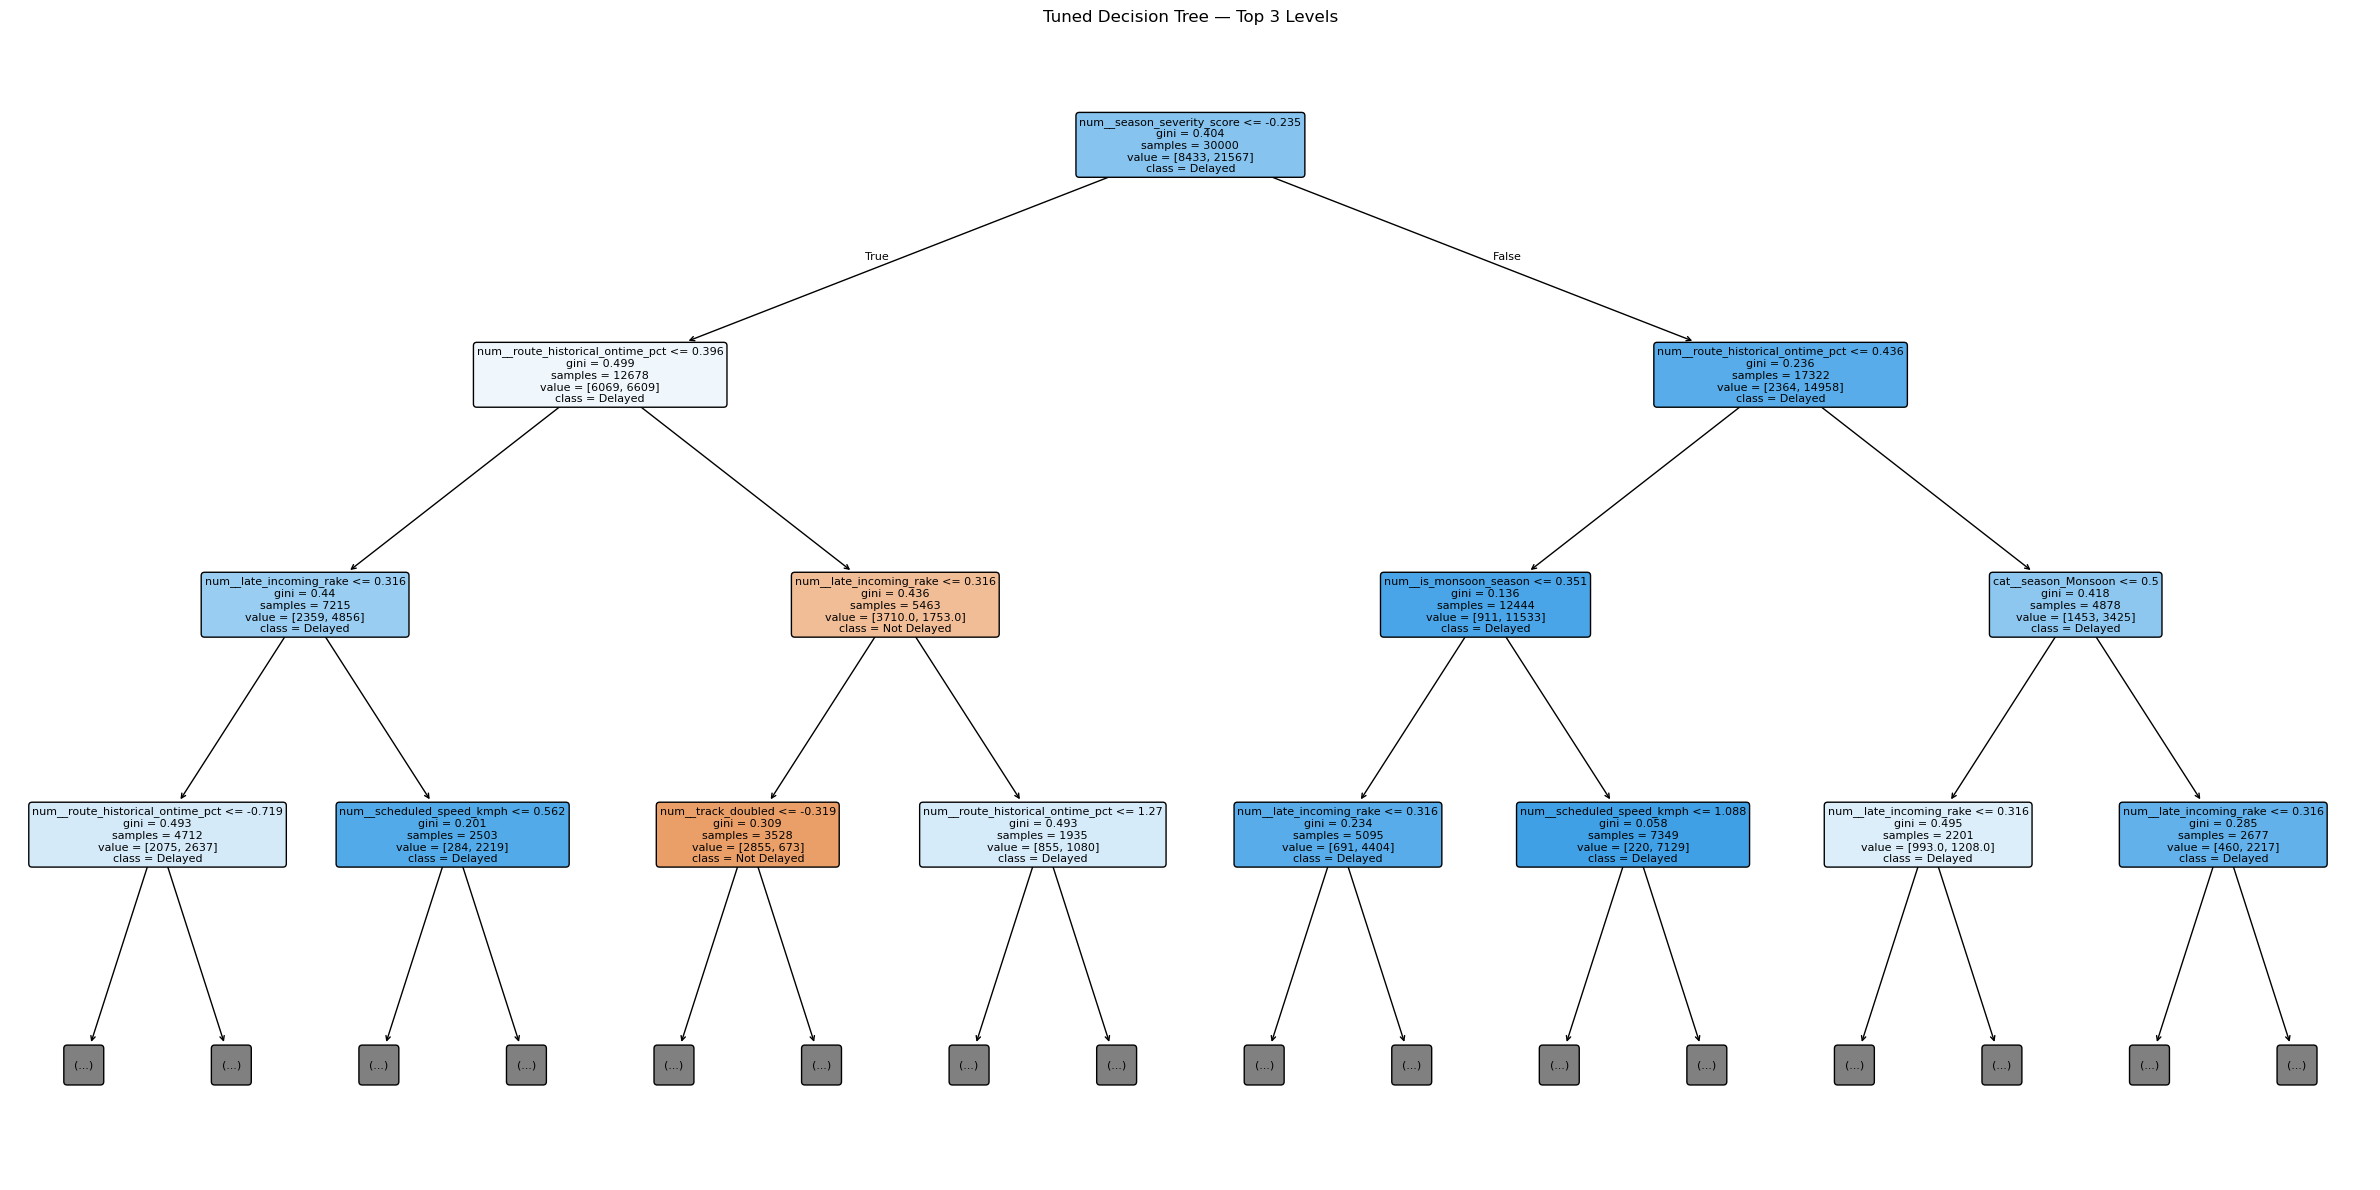

In [48]:
# Decision Tree Visualization

tree_model = best_dtree.named_steps["classifier"]

tree_feature_names = (
    best_dtree
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["Not Delayed", "Delayed"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Tuned Decision Tree — Top 3 Levels")
plt.tight_layout()
plt.show()

**Observation:** The tuned `max_depth` and its five-fold cross-validation Accuracy must be taken from the GridSearchCV output. The tree visualization shows the main decision rules learned by the tuned classifier.

### 15.5 Support Vector Machine — Hyperparameter Tuning

The `C` value and kernel are tuned using five-fold cross-validation. The same SVD representation used by the baseline SVC pipeline is retained in the tuning pipeline.

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split

# Use a smaller subset specifically for SVM hyperparameter tuning
SVM_TUNE_SIZE = min(5000, len(X_model_train))

X_svm_tune, _, y_svm_tune, _ = train_test_split(
    X_model_train,
    y_model_train,
    train_size=SVM_TUNE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_model_train
)

print("SVM tuning dataset:")
print("X:", X_svm_tune.shape)
print("y:", y_svm_tune.shape)


# SVM pipeline
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("svd", TruncatedSVD(
        n_components=20,
        random_state=RANDOM_STATE
    )),
    ("classifier", SVC(
        probability=False,
        random_state=RANDOM_STATE
    ))
])


# Smaller parameter grid
svm_param_grid = {
    "classifier__C": [1, 10],
    "classifier__kernel": ["linear", "rbf"]
}


# GridSearchCV
svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


print("\nStarting SVM GridSearch...")

svm_grid.fit(X_svm_tune, y_svm_tune)


print("\nBest SVM parameters:")
print(svm_grid.best_params_)

print("\nBest 3-fold CV accuracy:")
print(svm_grid.best_score_)

best_svm = svm_grid.best_estimator_

SVM tuning dataset:
X: (5000, 41)
y: (5000,)

Starting SVM GridSearch...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best SVM parameters:
{'classifier__C': 1, 'classifier__kernel': 'linear'}

Best 3-fold CV accuracy:
0.8398020275896801


**Observation:** The best SVM `C` value, kernel, and cross-validation Accuracy must be recorded from the actual GridSearchCV output. The comparison should be based on the generated results rather than a pre-written expected winner.

### 15.6 Tuning Improvement Summary

The original and tuned KNN, Decision Tree, and SVM models are compared using the same common evaluation subset.

In [53]:
tuning_summary = pd.DataFrame([
    {
        "Model": "KNN",
        "Before Accuracy": accuracy_score(
            y_eval, knn.predict(X_eval)
        ),
        "After Accuracy": accuracy_score(
            y_eval, best_knn.predict(X_eval)
        ),
        "Best Params": knn_grid.best_params_
    },
    {
        "Model": "Decision Tree",
        "Before Accuracy": accuracy_score(
            y_eval, dtree.predict(X_eval)
        ),
        "After Accuracy": accuracy_score(
            y_eval, best_dtree.predict(X_eval)
        ),
        "Best Params": dt_grid.best_params_
    },
    {
        "Model": "SVM",
        "Before Accuracy": accuracy_score(
            y_eval, svm.predict(X_eval)
        ),
        "After Accuracy": accuracy_score(
            y_eval, best_svm.predict(X_eval)
        ),
        "Best Params": svm_grid.best_params_
    }
])

pd.set_option("display.max_colwidth", None)

display(tuning_summary.round(3))

,Model,Before Accuracy,After Accuracy,Best Params
0,KNN,0.808,0.832,"{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 20}"
1,Decision Tree,0.829,0.833,{'classifier__max_depth': 7}
2,SVM,0.844,0.841,"{'classifier__C': 1, 'classifier__kernel': 'linear'}"


**Observation:** The tuning table shows whether KNN, Decision Tree, and SVM improved or decreased in test/evaluation Accuracy after hyperparameter tuning. Report the actual before/after values produced by this notebook during the review.

### 15.7 Cross-Validation of Top Two Models

Five-fold cross-validation is performed on the two highest-Accuracy models from the preliminary comparison. The models are selected from the actual comparison table, not hard-coded.

In [54]:
top_2_names = comparison_df.head(2)["Model"].tolist()

model_lookup = {
    "Logistic Regression": log_reg,
    "KNN": knn,
    "Naive Bayes": nb,
    "Decision Tree": dtree,
    "SVM": svm
}

top_2_models = {
    name: model_lookup[name]
    for name in top_2_names
}

cv_results = []

for name, model in top_2_models.items():
    scores = cross_val_score(
        model,
        X_model_train,
        y_model_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "CV Standard Deviation": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df.round(3))

,Model,Mean CV Accuracy,CV Standard Deviation
0,Logistic Regression,0.860,0.004
1,SVM,0.844,0.005


**Observation:** Five-fold cross-validation reports the mean Accuracy and standard deviation for the two models selected from the preliminary comparison. A smaller standard deviation indicates less variation in Accuracy across folds, while the mean indicates the average cross-validated performance.

## 16. Review 1 Summary

The five Review-1 Classification Part-A algorithms were implemented using a common cleaned feature set and stratified train/test split.

- Logistic Regression
- K-Nearest Neighbors
- Gaussian Naive Bayes
- Decision Tree Classifier
- Support Vector Classifier

The workflow includes dataset audit, target analysis, numerical and categorical EDA, correlation analysis, feature-target relationships, duplicate checking, IQR outlier analysis, leakage/identifier handling, feature engineering, stratified splitting, encoding, scaling, model training, evaluation, confusion matrices, ROC curves, algorithm-specific analysis, hyperparameter tuning, tuning-improvement comparison, and five-fold cross-validation of the two preliminary top models.

The final factual observations and numerical comparisons should be taken from the outputs generated when this notebook is run on the supplied dataset.